![Kenya Food Price Early Warning System](images/banner.png)

# Kenya Food Price Early Warning System


Forecasting staple food prices across Kenyan markets to give farmers, traders, and food security actors the early signal they currently lack.

## 1. Business Understanding

## 1.1 Background

Food prices in Kenya are highly seasonal and can change sharply across markets. Staples such as maize and beans are affected by harvest cycles, rainfall, supply conditions, and limited access to timely market information.

For farmers, this creates a difficult decision: sell early and risk missing a better price, or wait and risk a price drop. Traders and institutions face a similar problem when deciding when to buy, store, release, or distribute food.

The problem is not a lack of historical data. Kenya has publicly available market price data, but this information is mainly used to understand what has already happened.

This project aims to turn that historical information, together with weather data, into a forward-looking system that shows **where prices are likely to move and when unusual price changes may be starting.**

## 1.2 Problem Statement

Farmers, traders, and food security institutions often make decisions using current or historical prices rather than reliable forecasts of what may happen next.

This can lead to poor selling and buying decisions, increased inventory risk, and delayed responses to food price shocks. Institutions may only act once a shortage or price increase is already visible.

The core problem is therefore not the absence of data. It is the lack of a system that combines historical prices and external factors such as weather to produce **market-specific forecasts and early warnings.**

## 1.3 Business Objectives

The project aims to:

1. **Provide forward-looking price visibility**  
   Forecast commodity prices 2–3 months ahead for individual markets.

2. **Detect emerging price shocks**  
   Identify when actual prices begin to move significantly away from expected prices.

3. **Improve access to market intelligence**  
   Present forecasts and trends through a simple interactive dashboard that non-technical users can understand.

4. **Support institutional decisions**  
   Provide quantitative signals that can support decisions around food reserves, subsidies, procurement, and humanitarian response.

5. **Build a reproducible system**  
   Create an automated pipeline from data collection and processing to forecasting and dashboard deployment.

### 1.4 Stakeholder Analysis

The system is designed for people who make decisions around food prices, from farmers and traders to government and humanitarian organizations.

**Smallholder Farmers and Cooperatives**
Need to decide when to sell, how much to sell, and whether holding stock could lead to a better return. Price forecasts can give them greater visibility into upcoming market conditions.

**Traders and Market Intermediaries**
Need to decide when and where to buy, store, and sell commodities. Forecasts can help them manage inventory and reduce the risk of buying at a peak or holding through a price decline.

**County Agricultural Offices and NDMA**
Need early signals of localized food price stress. Market-level forecasts and anomaly alerts can help them identify emerging risks before they become wider food security problems.

**NGOs and Humanitarian Organizations**
Need to plan procurement and cash-based interventions efficiently. Earlier visibility into price movements can help them act before rising prices reduce the purchasing power of their interventions.

**National Cereals and Produce Board**
Needs to make better decisions around strategic reserves, procurement, and price stabilization. Forecasts can provide an additional signal when deciding when to buy or release stock.

**Urban Consumers and Low-Income Households**
Are highly sensitive to changes in staple food prices. Earlier information about expected price movements can help households and organizations supporting them prepare for potential increases.

**Food Processors and Millers**
Need predictable input costs to manage production and pricing. Forward-looking commodity prices can support better procurement and planning.

Across these groups, the common need is **timely, market-specific information about where food prices are heading**. The forecasting and anomaly detection components are designed to provide that signal.


## 1.5 Business Success Criteria

The project will be considered successful if:

- Forecasts perform better than a simple baseline such as the last observed price or seasonal average.
- The anomaly detection system identifies meaningful price shocks without producing excessive false alarms.
- A non-technical user can select a market and commodity and quickly understand the expected price, forecast range, and alert status.
- The entire data pipeline is reproducible and can be refreshed without significant manual work.
- The system uses reliable and accessible public data sources so it can be extended beyond the capstone.

## 1.6 Data Mining Goals

The data science work will focus on five main tasks:

1. Build a **Prophet forecasting model** as the baseline.
2. Build an **LSTM model** for comparison.
3. Combine WFP Kenya food price data with NASA POWER weather data using market location and date.
4. Build a **residual-based anomaly detection system** to identify unusual price movements.
5. Compare the models using **MAE and MAPE** across commodities and markets.

The final forecasts and alerts will be presented through an interactive **Streamlit dashboard**.

## 1.7 Data Mining Success Criteria

The technical implementation will be considered successful if:

- The forecasting models outperform the chosen naive baseline across most market-commodity combinations.
- Forecast accuracy is evaluated using MAE and MAPE.
- The anomaly detector identifies historical price shocks while limiting false alerts.
- The price and weather datasets can be joined with minimal data loss.
- The pipeline can run end-to-end with minimal manual intervention.
- The deployed dashboard works reliably for the selected markets and commodities.

## 1.8 Hypotheses Guiding the Analysis

The analysis will test six hypotheses:

- **H1:** Maize prices follow a seasonal pattern around harvest periods.
- **H2:** Rainfall has a measurable lagged relationship with future commodity prices.
- **H3:** Price patterns differ significantly between markets.
- **H4:** Maize and bean prices show a relationship because they are commonly used as staple food substitutes.
- **H5:** Price volatility increases during drought periods.
- **H6:** Changes in wholesale prices are reflected in retail prices within one to two weeks.

These hypotheses will guide the exploratory analysis, feature engineering, modelling, and evaluation throughout the project.

## 2. Data Understanding

This section is highly  focused on understanding the data before cleaning, joining, and modelling.

The project uses two main data sources: the **WFP Kenya Food Prices dataset**, sourced through HDX, and daily weather data from the **NASA POWER API**.

The goal is to understand what each dataset contains, assess its quality, and look for early patterns that can help test the hypotheses from the Business Understanding phase.


### 2.1 Data Collection

The project uses two publicly accessible data sources.

**WFP Kenya Food Prices (HDX)**
Provides historical commodity prices by market, commodity, and date. This is the primary source for the target variable used in forecasting.

**NASA POWER API**
Provides daily weather observations, including rainfall and temperature. These variables are used as external features to test whether weather conditions can improve price forecasts.

The extraction date and source versions are recorded to ensure that the analysis can be reproduced using the same data snapshot.


In [1]:
# core libraries and notebook display settings
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests # used for routing and fetching our data and later in in demo(front end)
from datetime import datetime



In [2]:
# set display settings for the notebook

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [3]:
# record the date at which the last data was pulled.

extraction_date = datetime.now().strftime("%Y-%m-%d")

print(f"Data extraction date recorded: {extraction_date}")


Data extraction date recorded: 2026-09-04


In [4]:
# Load the Kenya food prices dataset. Add support for Kaggle and local loading seamlessly.

DATA_URL = (
    "https://data.humdata.org/dataset/"
    "e0d3fba6-f9a2-45d7-b949-140c455197ff/"
    "resource/517ee1bf-2437-4f8c-aa1b-cb9925b9d437/"
    "download/wfp_food_prices_ken.csv"
)

# define a filename
FILENAME = "wfp_food_prices_ken.csv"


def load_food_prices():
    """
    Load the Kenya food prices dataset.

    The function automatically checks for a Kaggle copy,
    a previously saved local copy, or the original source URL.

    It returns:
        pandas.DataFrame
            Raw Kenya food prices dataset.
    """

    # check if the notebook is running on Kaggle
    kaggle_root = "/kaggle/input"

    if os.path.exists(kaggle_root):

        # search for the dataset inside the Kaggle input directory
        for root, _, files in os.walk(kaggle_root):

            if FILENAME in files:

                kaggle_path = os.path.join(root, FILENAME)

                try:
                    prices_raw = pd.read_csv(kaggle_path)

                    print(f"Loaded dataset from Kaggle: {kaggle_path}")

                    return prices_raw

                except Exception as error:
                    print(f"Kaggle file could not be read: {error}")

    # check if a previously downloaded local copy exists
    if os.path.exists(FILENAME):

        try:
            prices_raw = pd.read_csv(FILENAME)

            print(f"Loaded local dataset: {FILENAME}")

            return prices_raw

        except Exception as error:
            print(f"Local file could not be read: {error}")

    # try downloading from the source URL
    print("Dataset not found locally. Trying the source URL...")

    try:
        response = requests.get(
            DATA_URL,
            timeout=30
        )

        response.raise_for_status()

        # save the downloaded file locally for future use
        with open(FILENAME, "wb") as file:
            file.write(response.content)

        prices_raw = pd.read_csv(FILENAME)

        print(f"Dataset downloaded and saved as '{FILENAME}'")

        return prices_raw

    except Exception as error:
        print(f"Download failed: {error}")

    # final fallback to the local file
    if os.path.exists(FILENAME):

        print("Using the previously saved local dataset.")

        return pd.read_csv(FILENAME)

    raise FileNotFoundError(
        "Could not load the Kenya food prices dataset. "
        "Check your internet connection or provide a local copy."
    )


In [5]:
# Load the dataset
prices_raw = load_food_prices()

# Output the first 5 rows
prices_raw.head()

Loaded local dataset: wfp_food_prices_ken.csv


,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize (white),67,90 KG,actual,Wholesale,KES,1480.00,20.58
1,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans,50,KG,actual,Wholesale,KES,33.63,0.47
2,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans (dry),262,90 KG,actual,Wholesale,KES,3246.00,45.15
3,2006-01-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Maize (white),67,KG,actual,Retail,KES,17.00,0.24
4,2006-01-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Potatoes (Irish),148,50 KG,actual,Wholesale,KES,1249.99,17.39


In [6]:
# drop the units/description row if present, then fix dtypes 

def clean_price_data(prices_raw):
    """Clean and convert data types in the raw price dataset."""

    # Remove the units/description row if present
    if prices_raw.iloc[0].astype(str).str.startswith("#").any():

        prices = prices_raw.iloc[1:].reset_index(drop=True)

    else:

        prices = prices_raw.copy()

    # Convert date and price columns to the correct data types
    prices["date"] = pd.to_datetime(
        prices["date"],
        errors="coerce"
    )

    prices["price"] = pd.to_numeric(
        prices["price"],
        errors="coerce"
    )

    # Convert USD price if the column exists
    if "usdprice" in prices.columns:

        prices["usdprice"] = pd.to_numeric(
            prices["usdprice"],
            errors="coerce"
        )

    return prices


In [7]:
prices = clean_price_data(prices_raw)

In [8]:
print(f"Rows: {prices.shape[0]}, Columns: {prices.shape[1]}")
print(f"Date range: {prices['date'].min()} to {prices['date'].max()}")

Rows: 27763, Columns: 16
Date range: 2006-01-15 00:00:00 to 2026-08-15 00:00:00


In [9]:
# Get a sample of daily weather data from the NASA POWER API.
def get_weather_sample(
    latitude,
    longitude,
    start="20240101",
    end="20240131"
):
    """

    It returns:
        dict
            Weather parameters returned by the API.
    """

    power_url = "https://power.larc.nasa.gov/api/temporal/daily/point"

    params = {
        "parameters": "T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M",
        "community": "ag",
        "longitude": longitude,
        "latitude": latitude,
        "start": start,
        "end": end,
        "format": "JSON",
    }

    # ping the url and pass a timeout to avoid out of control requests
    response = requests.get(
        power_url,
        params=params,
        timeout=30
    )

    # raise an error if the API request failed
    response.raise_for_status()
    print(f" status code {response.status_code}")


    power_sample = response.json()

    return power_sample["properties"]["parameter"]




In [10]:
# sample call for Nairobi to confirm the API and response structure
nairobi_lat, nairobi_lon = -1.2864, 36.8172

sample_params = get_weather_sample(
    latitude=nairobi_lat,
    longitude=nairobi_lon
)


 status code 200


In [11]:

print("Parameters returned:", list(sample_params.keys()))
print("Sample PRECTOTCORR values:", list(sample_params["PRECTOTCORR"].items())[:5])

Parameters returned: ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M']
Sample PRECTOTCORR values: [('20240101', 0.31), ('20240102', 1.38), ('20240103', 0.28), ('20240104', 1.51), ('20240105', 1.56)]


### NASA POWER Weather Variables

The NASA POWER API provides several weather variables that can be used to understand conditions that may influence commodity prices.

| Parameter | Description | Unit |
|---|---|---|
| `T2M` | Average air temperature measured 2 meters above the surface | °C |
| `T2M_MAX` | Maximum air temperature measured at 2 meters | °C |
| `T2M_MIN` | Minimum air temperature measured at 2 meters | °C |
| `T2M_RANGE` | Difference between the daily maximum and minimum temperature | °C |
| `RH2M` | Relative humidity measured at 2 meters | % |
| `WS2M` | Average wind speed measured at 2 meters | m/s |
| `PS` | Atmospheric pressure at the surface | kPa |
| `PRECTOTCORR` | Bias-corrected total precipitation | mm/day |
| `ALLSKY_SFC_SW_DWN` | Total solar radiation reaching the surface under all sky conditions | kW-hr/m²/day |

For this project, **rainfall and temperature** are the primary weather variables of interest because they have the strongest potential relationship with agricultural production and future commodity prices.

### 2.2 Data Description

Before combining the datasets, we first need to understand how each one is structured.

The **price dataset** contains one observation for a specific commodity, market, and date.

The **weather dataset** contains daily weather observations for a specific geographic location.

This structure allows the two datasets to be joined using **market location and date**.


In [12]:
# column level summary: dtype, uniqueness, missingness
data_dictionary = pd.DataFrame({
    "column": prices.columns,

    "dtype": [str(prices[col].dtype) for col in prices.columns],

    "n_unique": [prices[col].nunique() for col in prices.columns],

    "n_missing": [prices[col].isna().sum() for col in prices.columns],

    "pct_missing": [(prices[col].isna().mean() * 100).round(2) for col in prices.columns],
})

data_dictionary

,column,dtype,n_unique,n_missing,pct_missing
0,date,datetime64[us],248,0,0.00
1,admin1,str,7,62,0.22
2,admin2,str,27,62,0.22
3,market,str,226,0,0.00
4,market_id,int64,226,0,0.00
5,latitude,float64,182,62,0.22
6,longitude,float64,184,62,0.22
7,category,str,8,0,0.00
8,commodity,str,51,0,0.00
9,commodity_id,int64,51,0,0.00


In [13]:
# scale and spread of the two numeric price fields

prices[["price", "usdprice"]].describe()

,price,usdprice
count,27763.000000,27763.000000
mean,1308.392522,11.949639
std,2583.636443,22.958342
min,5.000000,0.039000
25%,70.000000,0.610000
50%,130.000000,1.030000
75%,993.000000,9.045000
max,19800.000000,184.820000


In [14]:
# check for duplicate rows at the expected grain

grain_columns = ["date", "market", "commodity", "pricetype"]

duplicate_count = prices.duplicated(subset=grain_columns).sum()

In [15]:
print(f"Duplicate rows at (date, market, commodity, pricetype) grain: {duplicate_count}")
print(f"Unique markets: {prices['market'].nunique()}")
print(f"Unique commodities: {prices['commodity'].nunique()}")
print(f"Unique admin1 regions: {prices['admin1'].nunique()}")

Duplicate rows at (date, market, commodity, pricetype) grain: 0
Unique markets: 226
Unique commodities: 51
Unique admin1 regions: 7


### 2.3 Exploratory Data Analysis

Exploratory analysis is used to understand the main patterns in the price and weather data.

We first examine the individual variables to understand their distributions, ranges, and data coverage. We then look at relationships between variables, with a focus on how weather conditions relate to commodity prices.

Maize and beans are the main commodities of interest because they are central to the business objectives of the project.


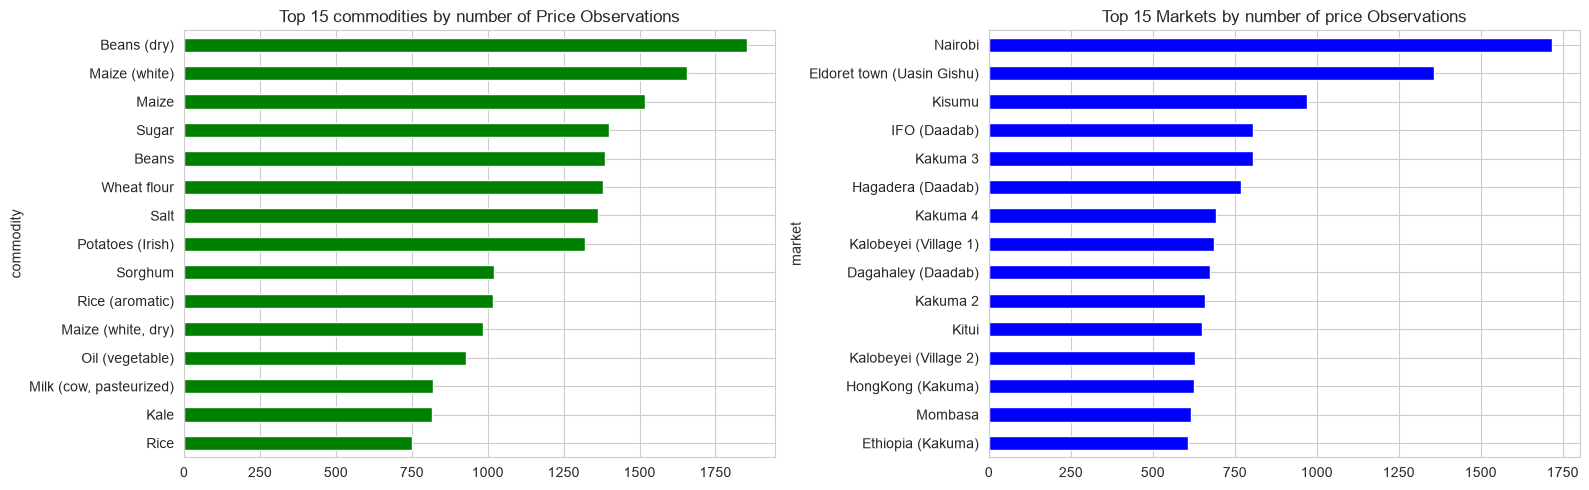

In [16]:
# top commodities and markets by number of price observation -- univariate analysis
commodity_counts = prices['commodity'].value_counts().head(15)
market_counts = prices["market"].value_counts().head(15)

#plot
fig, axes = plt.subplots(1,2, figsize=(16,5))
commodity_counts.plot(
    kind="barh", 
    ax=axes[0], 
    color='green')

axes[0].set_title("Top 15 commodities by number of Price Observations")
axes[0].invert_yaxis() #invert y-axis of first plot only

market_counts.plot(
    kind="barh", 
    ax=axes[1], 
    color='blue')

axes[1].set_title("Top 15 Markets by number of price Observations")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


Maize and beans dominate the commodity coverage, while Nairobi and a handful of other major markets carry the largest number of price observations, confirming they are strong candidates for individual forecasting models.

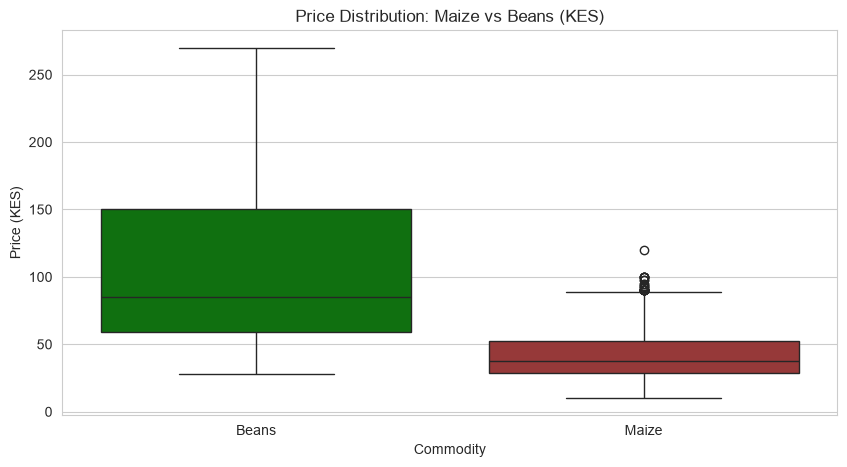

In [17]:
# price spread for the two priority commodities (Univariate)
priority_commodities = ["Maize", "Beans"]
subset = prices[prices["commodity"].isin(priority_commodities)]

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=subset, 
    x="commodity", 
    y="price", 
    palette=["green", "brown"],
    hue='commodity'
    )
plt.title("Price Distribution: Maize vs Beans (KES)")
plt.ylabel("Price (KES)")
plt.xlabel("Commodity")
plt.show()

Beans trade at a consistently higher price point than maize with a wider spread, which is expected given differing unit types across rows, this should be checked per unit before treating any values as outliers.

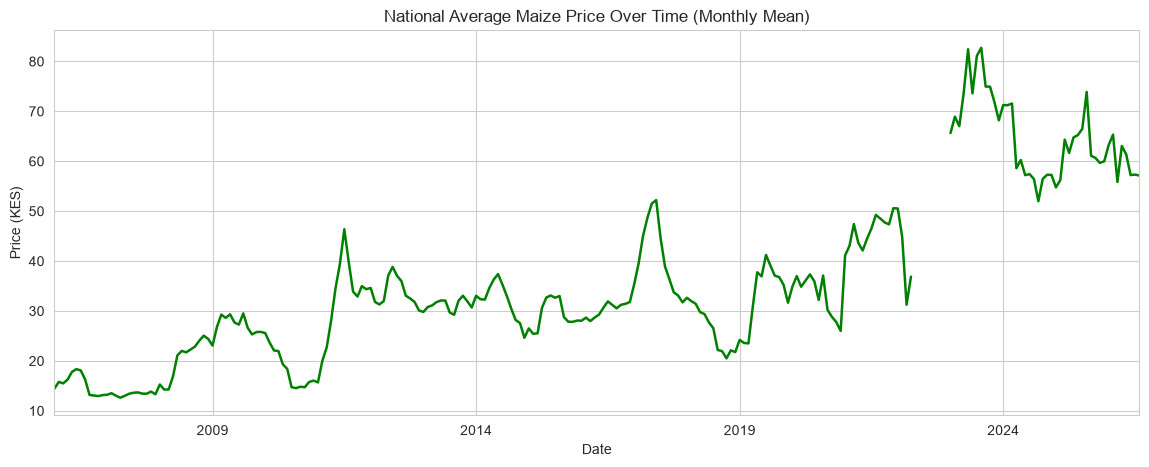

In [18]:
# national average maize price by month (univariate)
maize = prices[prices["commodity"] == "Maize"].copy()
maize_monthly = maize.groupby(
    pd.Grouper(
        key="date", 
        freq="ME")
        )["price"].mean()

plt.figure(figsize=(14, 5))
maize_monthly.plot(color="green", linewidth=1.8)
plt.title("National Average Maize Price Over Time (Monthly Mean)")
plt.ylabel("Price (KES)")
plt.xlabel("Date")
plt.show()

Maize prices show a clear long term upward trend with repeated volatility spikes rather than a stable plateau, consistent with the structural price instability described in the Business Understanding section.

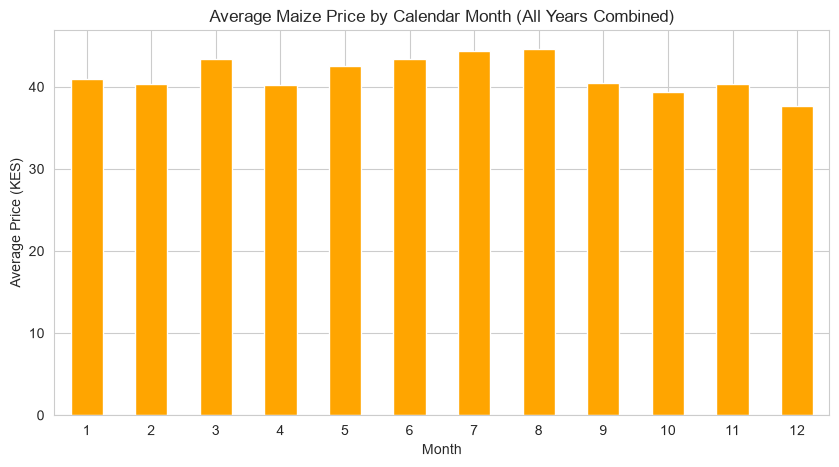

In [19]:
# average maize price by calendar month, all years combined (univariate)
maize["month"] = maize["date"].dt.month
seasonal_avg = maize.groupby("month")["price"].mean()

plt.figure(figsize=(10, 5))
seasonal_avg.plot(kind="bar", color="orange")
plt.title("Average Maize Price by Calendar Month (All Years Combined)")
plt.xlabel("Month")
plt.ylabel("Average Price (KES)")
plt.xticks(rotation=0)
plt.show()

Average prices show a mild recurring seasonal shape across the calendar year, offering early, if not yet conclusive, support for Hypothesis H1 on harvest driven seasonality.

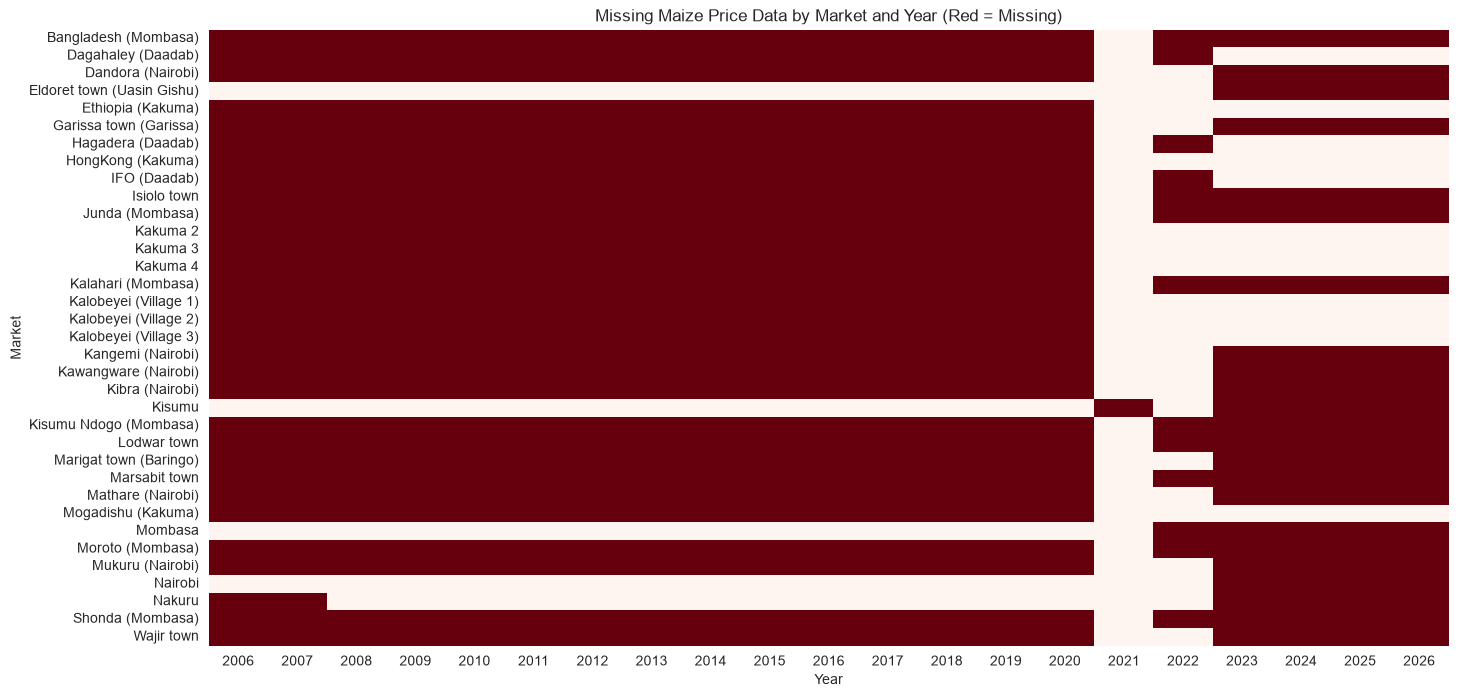

In [20]:
# missing maize price coverage by market and year (univariate)
pivot_check = maize.pivot_table(
    index="market",
    columns=maize["date"].dt.year,
    values="price",
    aggfunc="mean"
)

plt.figure(figsize=(16, 8))
sns.heatmap(pivot_check.isna(), cbar=False, cmap="Reds")
plt.title("Missing Maize Price Data by Market and Year (Red = Missing)")
plt.xlabel("Year")
plt.ylabel("Market")
plt.show()

Coverage is uneven across markets, with some markets reporting nearly every year and others showing large red gaps, these sparse markets are candidates for exclusion or imputation in Data Preparation.

In [21]:
# flag maize price outliers using the iqr method (univariate analysis)
q1 = maize["price"].quantile(0.25)
q3 = maize["price"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = maize[(maize["price"] < lower_bound) | (maize["price"] > upper_bound)]

In [22]:
print(f"IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}] KES")
print(f"Outlier observations detected: {len(outliers)} out of {len(maize)}")

IQR bounds: [-7.88, 88.73] KES
Outlier observations detected: 24 out of 1518


In [23]:
outliers[["date", "market", "price"]].sort_values("price", ascending=False).head(10)

,date,market,price
23557,2023-08-15,Dagahaley (Daadab),120.00
23171,2023-05-15,Ethiopia (Kakuma),100.00
24191,2024-01-15,Dagahaley (Daadab),100.00
23730,2023-09-15,HongKong (Kakuma),100.00
23719,2023-09-15,Ethiopia (Kakuma),100.00
24462,2024-03-15,HongKong (Kakuma),100.00
23485,2023-07-15,Kakuma 3,97.50
25025,2024-08-15,Dagahaley (Daadab),97.50
23206,2023-05-15,Kakuma 3,95.00
24415,2024-03-15,Dagahaley (Daadab),94.41


### 2.4 Weather Data Exploration

Rainfall and temperature are the two variables most directly tied to agricultural output, and by extension to price formation several months later. Kenya has a  known bimodal rainfall pattern, long rains from March to May and short rains from October to December,which provides a natural benchmark against which the retrieved data can be validated.

In [24]:
# daily rainfall and temperature for Nairobi, full year 2023 (univariate)
power_url = "https://power.larc.nasa.gov/api/temporal/daily/point"

params_full_year = {
    "parameters": "T2M,PRECTOTCORR",
    "community": "ag",
    "longitude": nairobi_lon,
    "latitude": nairobi_lat,
    "start": "20230101",
    "end": "20231231",
    "format": "JSON",
}

response_year = requests.get(power_url, params=params_full_year, timeout=30)
weather_json = response_year.json()["properties"]["parameter"]

weather_df = pd.DataFrame({
    "date": pd.to_datetime(list(weather_json["T2M"].keys()), format="%Y%m%d"),
    "temperature": list(weather_json["T2M"].values()),
    "rainfall": list(weather_json["PRECTOTCORR"].values()),
})

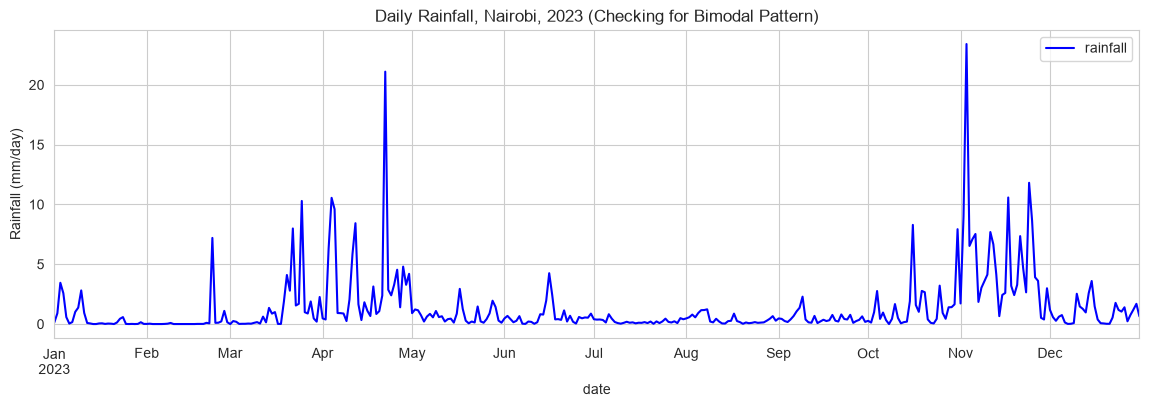

In [25]:
weather_df.set_index("date")[["rainfall"]].plot(figsize=(14, 4), color="blue")
plt.title("Daily Rainfall, Nairobi, 2023 (Checking for Bimodal Pattern)")
plt.ylabel("Rainfall (mm/day)")
plt.show()

Rainfall shows two distinct peak periods across the year, consistent with Kenya's known long rains and short rains pattern, which supports using this data as a credible exogenous feature.

### 2.5 Price and Weather Relationship

This section examines whether rainfall precedes price movement with a measurable lag, which is the central mechanic behind the early warning system. Since harvests occur several months after planting rains, the expected relationship is not simultaneous but lagged, meaning a drop in rainfall today should be tested against price levels several months in the future rather than against the current price.

In [26]:
# test rainfall to price correlation at 0 to 6 month lags
monthly_rainfall = weather_df.set_index("date")["rainfall"].resample("ME").sum()
monthly_price = maize_monthly

combined = pd.DataFrame({"rainfall": monthly_rainfall, "price": monthly_price}).dropna()

lag_results = {}
for lag in range(0, 7):
    shifted_rainfall = combined["rainfall"].shift(lag)
    lag_results[lag] = shifted_rainfall.corr(combined["price"])

lag_series = pd.Series(lag_results)

In [27]:
print("Correlation between rainfall (lagged) and maize price:")
print(lag_series.round(3))

Correlation between rainfall (lagged) and maize price:
0   -0.168
1   -0.101
2   -0.036
3    0.347
4    0.639
5    0.154
6   -0.183
dtype: float64


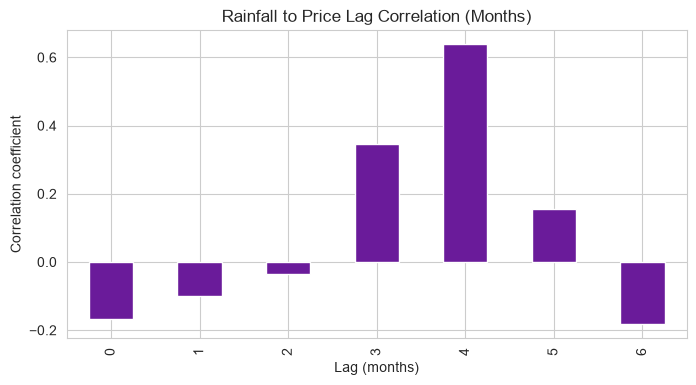

In [28]:
# rainfall to price lag correlation (Bivariate)
lag_series.plot(kind="bar", figsize=(8, 4), color="#6A1B9A")
plt.title("Rainfall to Price Lag Correlation (Months)")
plt.xlabel("Lag (months)")
plt.ylabel("Correlation coefficient")
plt.show()

This lag test currently uses only one calendar year of Nairobi weather against a multi year national price series, so the correlation values are indicative rather than conclusive, the proper version of this test happens once weather is pulled per market across the full date range in Data Preparation.

### 2.6 Coordinate Completeness

Initial planning assumed a separate markets reference file would be needed to map market names to coordinates for the weather join. Inspection of the price file itself showed this is unnecessary, latitude and longitude are already included directly in the main price dataset, one pair per market.

In [29]:
# confirm lat/lon exist directly in the price data
coordinate_columns = [col for col in prices.columns if "lat" in col.lower() or "lon" in col.lower()]
coord_check = prices.groupby("market")[coordinate_columns].nunique()

In [30]:
print("Coordinate related columns found:", coordinate_columns)
coord_check.head(10)

Coordinate related columns found: ['latitude', 'longitude']


,latitude,longitude
market,,
Adele Center,1,1
Alango Arba,1,1
Alemsekon,1,1
Alinjugur,1,1
Alungu,1,1
Amaya,1,1
Aposta,1,1
Archers Post,1,1
Ashabito,1,1


In [31]:
# identify which markets are missing coordinates
missing_coords = prices[prices["latitude"].isna()]["market"].unique()

In [32]:
print(f"Markets with missing coordinates: {len(missing_coords)}")
print(missing_coords)

Markets with missing coordinates: 1
<ArrowStringArray>
['Hola (Tana River)']
Length: 1, dtype: str


### 2.7 Data Quality Summary

The data is generally suitable for analysis, but a few issues need to be addressed before modelling.

* **Commodity names:** Maize appears under different labels. These will need to be reviewed and consolidated where appropriate.
* **Duplicates:** No duplicate observations were found at the market, commodity, date, and price type level.
* **Outliers:** A small number of maize price observations were flagged using the IQR method. These will be reviewed rather than removed automatically.
* **Market coordinates:** One market is missing latitude and longitude and will be excluded from the weather join.
* **Date coverage:** The price data spans from January 2006 to August 2026, providing a long historical period for analysis.

These findings will guide the data cleaning and preparation steps before modelling.


### 2.8 Initial Insights and Transition to Data Preparation

The data is generally clean and suitable for the next stage. We found no duplicate observations, and almost all markets have the coordinates needed to connect them with weather data.

The rainfall analysis also showed a relationship between rainfall and prices at a four-month lag, providing early support for **H2**. This is an initial finding and will be tested further using the full dataset.

The main issue to resolve is the way maize is labelled. Different maize variants appear as separate commodities and may have different price scales and units. This needs to be handled before outlier detection and modelling.

These findings guide the cleaning, transformation, and feature engineering steps in the **Data Preparation** phase.


## 3. Data Preparation

This phase prepares the data for analysis and modelling based on the findings from Data Understanding.

The data will be cleaned, transformed, and combined with weather data. Commodity labels will be preserved as reported in the source data rather than merging products that may have different price behaviour.

We will also check market and commodity coverage before making decisions about which data to use for modelling.


### 3.1 Commodity Landscape

Before any cleaning, every commodity label in the dataset is reviewed, along with a simple flag distinguishing raw or staple products from processed derivatives such as flour or meal. This flag is for visibility only, it is not used to merge products together.

In [33]:
commodity_overview = prices["commodity"].value_counts()
is_processed = prices["commodity"].str.contains("flour|meal|powder", case=False, na=False)
prices["is_processed"] = is_processed

In [34]:
print(f"Total distinct commodity labels: {prices['commodity'].nunique()}")
print(f"Processed or derivative product rows: {is_processed.sum()}")
print(commodity_overview.head(30))

Total distinct commodity labels: 51
Processed or derivative product rows: 2815
commodity
Beans (dry)                   1854
Maize (white)                 1656
Maize                         1518
Sugar                         1401
Beans                         1386
Wheat flour                   1380
Salt                          1362
Potatoes (Irish)              1320
Sorghum                       1021
Rice (aromatic)               1017
Maize (white, dry)             983
Oil (vegetable)                927
Milk (cow, pasteurized)        821
Kale                           817
Rice                           752
Oil (vegetable, fortified)     749
Maize flour                    745
Maize flour (white)            690
Milk (UHT)                     626
Bananas                        591
Tomatoes                       519
Cabbage                        485
Onions (dry)                   470
Meat (goat)                    402
Potatoes (Irish, white)        401
Beans (yellow)                 380
M

### 3.2 Unit Audit

Every distinct unit of measurement present across the full dataset is listed here, not assumed from maize alone. Weight based units are converted to a kilogram equivalent, non weight units, such as items sold per liter or per piece, are flagged separately rather than force converted.

In [35]:
unit_counts = prices["unit"].value_counts()

In [36]:
print(unit_counts)

unit
KG        14595
90 KG      4118
L          2715
50 KG      1905
200 G      1362
500 ML      804
Unit        591
64 KG       518
13 KG       470
126 KG      459
400 G       178
Head         26
Bunch        22
Name: count, dtype: int64


In [37]:
unit_to_kg = {
    "KG": 1,
    "90 KG": 90,
    "64 KG": 64,
    "50 KG": 50,
    "26 KG": 26,
    "126 KG": 126,
    "13 KG": 13,
    "200 G": 0.2,
    "400 G": 0.4,
}

prices["kg_equivalent"] = prices["unit"].map(unit_to_kg)
prices["price_per_kg"] = prices["price"] / prices["kg_equivalent"]

In [38]:
unmapped_units = prices[prices["kg_equivalent"].isna()]["unit"].unique()
print(f"Unmapped units, genuinely non weight based: {unmapped_units}")
print(f"Rows converted to price per kg: {prices['price_per_kg'].notna().sum()} out of {len(prices)}")

Unmapped units, genuinely non weight based: <ArrowStringArray>
['500 ML', 'L', 'Unit', 'Bunch', 'Head']
Length: 5, dtype: str
Rows converted to price per kg: 23605 out of 27763


### 3.3 Retail Price Selection

Retail prices are selected as the primary modeling series. This is a deliberate scoping decision, not an oversight, retail is the price point smallholder farmers, cooperatives, and urban consumers, the majority of beneficiary groups in the stakeholder analysis, actually transact on and can act upon directly. Wholesale price forecasting, most relevant to traders, NCPB, and millers, is a natural extension of this same pipeline, since wholesale rows remain intact in the source data and require no new data collection, only rerunning the completeness and modeling steps against `pricetype == "Wholesale"` instead. This is documented here as a defined next phase rather than an unaddressed gap.

In [39]:
retail = prices[prices["pricetype"] == "Retail"].copy()
print(f"Retail rows: {len(retail)} out of {len(prices)} total rows")

Retail rows: 18608 out of 27763 total rows


In [40]:
wholesale_rows = prices[prices["pricetype"] == "Wholesale"]
print(f"Wholesale rows available: {len(wholesale_rows)}")
print(f"Retail rows available: {len(retail)}")

Wholesale rows available: 9155
Retail rows available: 18608


### 3.4 Market and Commodity Completeness 

Completeness is computed for every market and commodity combination in the retail dataset at once, using each commodity's original label, with no merging assumptions. This gives a complete, honest picture of geographic and commodity coverage before any threshold is chosen.

In [41]:
coverage = (
    retail
    .groupby(["market", "commodity"])["date"]
    .nunique()
    .reset_index(name="months_reported")
)

total_months_available = retail["date"].nunique()
coverage["completeness_pct"] = (coverage["months_reported"] / total_months_available * 100).round(1)

In [42]:
print(f"Total market-commodity pairs: {len(coverage)}")
for threshold in [30, 40, 50, 60, 70]:
    qualifying = coverage[coverage["completeness_pct"] >= threshold]
    print(f"At {threshold} percent threshold: {len(qualifying)} pairs, {qualifying['market'].nunique()} markets, {qualifying['commodity'].nunique()} commodities")

Total market-commodity pairs: 2546
At 30 percent threshold: 8 pairs, 5 markets, 5 commodities
At 40 percent threshold: 8 pairs, 5 markets, 5 commodities
At 50 percent threshold: 7 pairs, 4 markets, 5 commodities
At 60 percent threshold: 6 pairs, 3 markets, 5 commodities
At 70 percent threshold: 6 pairs, 3 markets, 5 commodities


In [43]:
# check the reporting span of each commodity
reporting_span = (
    retail
    .groupby(["market", "commodity"])["date"]
    .agg(first_reported="min", last_reported="max", months_reported="nunique")
    .reset_index()
)

reporting_span["active_months"] = (
    (reporting_span["last_reported"].dt.year - reporting_span["first_reported"].dt.year) * 12
    + (reporting_span["last_reported"].dt.month - reporting_span["first_reported"].dt.month)
    + 1
)

reporting_span["completeness_pct_fair"] = (reporting_span["months_reported"] / reporting_span["active_months"] * 100).round(1)

In [44]:
print(reporting_span[["first_reported", "last_reported"]].describe())
for threshold in [50, 60, 70, 80, 90]:
    qualifying = reporting_span[reporting_span["completeness_pct_fair"] >= threshold]
    print(f"At {threshold} percent fair completeness: {len(qualifying)} pairs, {qualifying['market'].nunique()} markets, {qualifying['commodity'].nunique()} commodities")

                   first_reported               last_reported
count                        2546                        2546
mean   2023-06-30 04:03:46.237235  2024-11-13 09:06:55.710919
min           2006-01-15 00:00:00         2020-08-15 00:00:00
25%           2023-12-15 00:00:00         2024-06-15 00:00:00
50%           2023-12-15 00:00:00         2024-12-15 00:00:00
75%           2024-03-15 00:00:00         2026-03-15 00:00:00
max           2026-07-15 00:00:00         2026-08-15 00:00:00
At 50 percent fair completeness: 1054 pairs, 178 markets, 36 commodities
At 60 percent fair completeness: 872 pairs, 161 markets, 36 commodities
At 70 percent fair completeness: 758 pairs, 160 markets, 36 commodities
At 80 percent fair completeness: 673 pairs, 159 markets, 36 commodities
At 90 percent fair completeness: 637 pairs, 157 markets, 33 commodities


### 3.5 Assessing Historical Coverage

Having enough observations does not always mean having enough history for seasonal modelling. To identify a reliable yearly pattern, we need to see that pattern repeat across multiple years.

We therefore assess each market and commodity based on both **data completeness and the number of years of available history**. Market-commodity pairs with deeper histories are suitable for models such as Prophet, while pairs with shorter histories can be evaluated using LSTM or simpler baseline models.

This ensures that each model is used only where the available history is sufficient for it to perform reliably.


In [45]:
reporting_span["years_active"] = ((reporting_span["last_reported"] - reporting_span["first_reported"]).dt.days / 365.25).round(1)

MIN_YEARS_ACTIVE = 1.0

long_history = reporting_span[
    (reporting_span["completeness_pct_fair"] >= 60) &
    (reporting_span["years_active"] >= 3)
]

recent_only = reporting_span[
    (reporting_span["completeness_pct_fair"] >= 60) &
    (reporting_span["years_active"] >= MIN_YEARS_ACTIVE) &
    (reporting_span["years_active"] < 3)
]

insufficient_data = reporting_span[
    (reporting_span["completeness_pct_fair"] >= 60) &
    (reporting_span["years_active"] < MIN_YEARS_ACTIVE)
]

In [46]:
print(f"Long history pairs (3+ years): {len(long_history)}")
print(f"Recent only pairs (1 to 3 years): {len(recent_only)}")
print(f"Insufficient data pairs (under 1 year, excluded from modelling): {len(insufficient_data)}")

Long history pairs (3+ years): 129
Recent only pairs (1 to 3 years): 46
Insufficient data pairs (under 1 year, excluded from modelling): 697


In [47]:
print(f"Long history pairs (3+ years, 60pct fair completeness): {len(long_history)}, {long_history['market'].nunique()} markets, {long_history['commodity'].nunique()} commodities")
print(f"Recent only pairs (under 3 years, 60pct fair completeness): {len(recent_only)}, {recent_only['market'].nunique()} markets, {recent_only['commodity'].nunique()} commodities")

Long history pairs (3+ years, 60pct fair completeness): 129, 21 markets, 21 commodities
Recent only pairs (under 3 years, 60pct fair completeness): 46, 6 markets, 15 commodities


In [48]:
for years in [1, 2, 3, 4]:
    qualifying = reporting_span[(reporting_span["completeness_pct_fair"] >= 60) & (reporting_span["years_active"] >= years)]
    print(f"At {years}+ years active: {len(qualifying)} pairs, {qualifying['market'].nunique()} markets, {qualifying['commodity'].nunique()} commodities")

At 1+ years active: 175 pairs, 27 markets, 23 commodities
At 2+ years active: 129 pairs, 21 markets, 21 commodities
At 3+ years active: 129 pairs, 21 markets, 21 commodities
At 4+ years active: 128 pairs, 21 markets, 21 commodities


### 3.6 Final Market Commodity list

The long history and recent only groups together define the full modeling scope. Each retains its original commodity label, market, and price type, with no products merged.

In [49]:
long_history["model_track"] = "prophet"
recent_only["model_track"] = "lstm"

shortlist = pd.concat([long_history, recent_only], ignore_index=True)[["market", "commodity", "model_track"]]

In [50]:
print(f"Total shortlisted market-commodity pairs: {len(shortlist)}")
print(f"Unique markets: {shortlist['market'].nunique()}")
print(f"Unique commodities: {shortlist['commodity'].nunique()}")

Total shortlisted market-commodity pairs: 175
Unique markets: 27
Unique commodities: 23


In [51]:
retail["kg_equivalent"] = retail["unit"].map(unit_to_kg)
retail["price_per_kg"] = retail["price"] / retail["kg_equivalent"]

modeling_data = retail.merge(shortlist, on=["market", "commodity"], how="inner")
modeling_data = modeling_data[modeling_data["price_per_kg"].notna()].copy()

In [52]:
print(f"Modeling ready rows: {len(modeling_data)}")
print(f"Rows dropped for non weight units: {len(retail.merge(shortlist, on=['market','commodity'])) - len(modeling_data)}")

Modeling ready rows: 6077
Rows dropped for non weight units: 1854


### 3.7 Outlier Recheck

Outlier bounds are recalculated on the corrected, unit standardized price per kilogram field, computed separately per commodity, since pooling different commodities together, the same mistake that distorted the earlier maize check, would produce meaningless bounds here too.

In [53]:
def flag_outliers(group):
    q1, q3 = group["price_per_kg"].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return group[(group["price_per_kg"] < lower) | (group["price_per_kg"] > upper)]

outliers_by_commodity = (
    modeling_data
    .groupby("commodity", group_keys=True)
    .apply(flag_outliers, include_groups=False)
    .reset_index(level=0)
)

In [54]:
print(f"Total outliers flagged: {len(outliers_by_commodity)} out of {len(modeling_data)}")
print(outliers_by_commodity["commodity"].value_counts())

Total outliers flagged: 69 out of 6077
commodity
Meat (camel)        26
Salt                17
Beans (dry)          8
Maize                5
Maize (white)        4
Rice                 3
Potatoes (Irish)     2
Sugar                2
Meat (beef)          1
Sorghum              1
Name: count, dtype: int64


### 3.8 Outlier Verification in salt commodity.

Manual inspection of the salt outliers shows a tight, plausible price cluster around 90 to 115 KES per kilogram, with a small tail extending toward 275 KES per kilogram concentrated in refugee camp markets such as Kakuma, Daadab, and Kalobeyei, where transport and supply chain costs are known to be higher. These are genuine price observations rather than conversion errors, and all flagged outliers across every commodity are retained in the dataset rather than removed, since the project's own anomaly detection layer is designed to act on exactly this kind of divergence.

In [55]:
salt_outliers = outliers_by_commodity[outliers_by_commodity["commodity"] == "Salt"]
print(salt_outliers[["market", "date", "price", "unit", "price_per_kg"]].to_string())

                     market       date  price   unit  price_per_kg
2059               Kakuma 4 2025-09-15  20.00  200 G        100.00
2065      Ethiopia (Kakuma) 2025-12-15  20.00  200 G        100.00
2068      HongKong (Kakuma) 2025-12-15  23.00  200 G        115.00
2073               Kakuma 3 2025-12-15  20.00  200 G        100.00
2076               Kakuma 4 2025-12-15  18.00  200 G         90.00
2127           IFO (Daadab) 2024-06-15  39.26  200 G        196.30
2298               Kakuma 4 2026-03-15  16.50  200 G         82.50
4840  Kalobeyei (Village 1) 2023-07-15  49.38  200 G        246.90
5733           IFO (Daadab) 2024-05-15  35.98  200 G        179.90
7034               Kakuma 3 2025-08-15  55.00  200 G        275.00
7428           IFO (Daadab) 2026-03-15  17.64  200 G         88.20
7482  Kalobeyei (Village 2) 2026-03-15  17.50  200 G         87.50
7520           IFO (Daadab) 2026-04-15  17.96  200 G         89.80
7619           IFO (Daadab) 2026-05-15  17.93  200 G         8

### 3.9 Outlier Persistence Classification

An IQR flag alone could not distinguish a genuine market shift, where prices settle at a new level and stay there, from a transient spike that reverts, or a data entry error that appears once and never repeats. Each flagged outlier is classified by comparing the price level in the months immediately after the flagged date against the baseline level in the months immediately before it. If the new level persists, it is treated as a genuine shift worth investigating further. If it reverts close to baseline, it is treated as a transient spike, a real but temporary event. This same logic is the direct precursor to the residual based anomaly detection layer planned for the final system, since both rely on comparing actual behavior against a recent baseline.

In [56]:
def classify_outlier(row, data, window=2):
    series = data[(data["market"] == row["market"]) & (data["commodity"] == row["commodity"])].sort_values("date")
    match = series[series["date"] == row["date"]]
    if match.empty:
        return "unknown"
    pos = series.index.get_loc(match.index[0])
    before = series.iloc[max(0, pos - window):pos]["price_per_kg"]
    after = series.iloc[pos + 1: pos + 1 + window]["price_per_kg"]
    if before.empty or after.empty:
        return "insufficient surrounding data"
    baseline = before.mean()
    reverted = abs(after.mean() - baseline) < abs(row["price_per_kg"] - baseline) * 0.5
    return "transient spike" if reverted else "persistent shift"

outliers_by_commodity["classification"] = outliers_by_commodity.apply(
    lambda row: classify_outlier(row, modeling_data), axis=1
)

In [57]:
print(outliers_by_commodity["classification"].value_counts())

classification
persistent shift                 45
transient spike                  22
insufficient surrounding data     2
Name: count, dtype: int64


In [58]:
persistent_shifts = outliers_by_commodity[outliers_by_commodity["classification"] == "persistent shift"]
persistent_shifts[["market", "commodity", "date", "price_per_kg"]].sort_values("date")

,market,commodity,date,price_per_kg
1251,Lodwar (Turkana),Maize (white),2017-03-15,90.70
1270,Lodwar (Turkana),Maize (white),2017-04-15,92.60
1303,Lodwar (Turkana),Maize (white),2017-06-15,100.00
1321,Lodwar (Turkana),Maize (white),2017-07-15,91.00
2712,Hagadera (Daadab),Meat (camel),2021-04-15,455.56
2865,Hagadera (Daadab),Meat (camel),2021-05-15,500.00
3016,Hagadera (Daadab),Meat (camel),2021-06-15,490.59
3321,Hagadera (Daadab),Meat (camel),2021-08-15,497.92
3473,Hagadera (Daadab),Meat (camel),2021-09-15,500.00
3749,Hagadera (Daadab),Meat (camel),2021-11-15,487.61


### 3.10 Handling Outliers

No flagged outliers are removed from the modeling dataset. Transient spikes are retained as genuine historical events and reserved as informal validation cases for the anomaly detection layer built later in the project. Persistent shifts are retained in the modeling data but a sample was manually reviewed to rule out unit or entry errors masquerading as real market changes, since a genuine shift and a silent data bug can produce an identical pattern in this test. Rows with insufficient surrounding data remain in the dataset but are not treated as evidence of either category, since there is not enough history on one side to judge them fairly.

### 3.10 Weather Retrieval at Scale

With the market and commodity shortlist finalized, daily rainfall and temperature data is retrieved from the NASA POWER API for every shortlisted market's coordinates, covering the full date range needed for modeling. A short pause between requests avoids triggering rate limiting on the API, given the number of markets involved.

In [59]:
import time

market_coords = modeling_data[["market", "latitude", "longitude"]].drop_duplicates()
weather_records = []

for _, row in market_coords.iterrows():
    params_loop = {
        "parameters": "T2M,PRECTOTCORR",
        "community": "ag",
        "longitude": row["longitude"],
        "latitude": row["latitude"],
        "start": "20060101",
        "end": "20260815",
        "format": "JSON",
    }
    resp = requests.get(power_url, params=params_loop, timeout=60)
    if resp.status_code == 200:
        param_data = resp.json()["properties"]["parameter"]
        df_market = pd.DataFrame({
            "date": pd.to_datetime(list(param_data["T2M"].keys()), format="%Y%m%d"),
            "temperature": list(param_data["T2M"].values()),
            "rainfall": list(param_data["PRECTOTCORR"].values()),
        })
        df_market["market"] = row["market"]
        weather_records.append(df_market)
    time.sleep(1)

weather_all = pd.concat(weather_records, ignore_index=True)

In [60]:
print(f"Markets retrieved: {weather_all['market'].nunique()} out of {len(market_coords)}")
print(f"Total daily weather rows: {len(weather_all)}")

Markets retrieved: 25 out of 26
Total daily weather rows: 188300


### 3.11 Weather Aggregation to Monthly

Price data is recorded monthly, while the retrieved weather data is daily, so weather is resampled to a monthly grain per market before joining, rainfall summed and temperature averaged, matching how each variable naturally aggregates over a month.

In [61]:
weather_monthly = (
    weather_all
    .set_index("date")
    .groupby("market")
    .resample("ME")
    .agg({"rainfall": "sum", "temperature": "mean"})
    .reset_index()
)

In [62]:
print(f"Monthly weather rows: {len(weather_monthly)}")
print(f"Markets represented: {weather_monthly['market'].nunique()}")

Monthly weather rows: 6200
Markets represented: 25


### 3.12 Lagged Weather Feature Engineering

The lag correlation test in Data Understanding found the strongest relationship between rainfall and maize price at a four month lag, with a secondary signal at three months. Both lags are engineered as explicit features here, computed per market so no market's lag mixes with another's history.

In [63]:
weather_monthly = weather_monthly.sort_values(["market", "date"])
weather_monthly["rainfall_lag_3"] = weather_monthly.groupby("market")["rainfall"].shift(3)
weather_monthly["rainfall_lag_4"] = weather_monthly.groupby("market")["rainfall"].shift(4)
weather_monthly["temperature_lag_3"] = weather_monthly.groupby("market")["temperature"].shift(3)
weather_monthly["temperature_lag_4"] = weather_monthly.groupby("market")["temperature"].shift(4)

### 3.13 Price and Weather Integration
Cleaned monthly prices are joined to the lagged monthly weather features on market and date. The weather table's own date column is dropped before the merge, since both tables otherwise carry a column named date, which would silently rename both to date_x and date_y and break every step downstream that references date directly.

In [64]:
modeling_data["date_month"] = modeling_data["date"].values.astype("datetime64[M]")
weather_monthly["date_month"] = weather_monthly["date"].values.astype("datetime64[M]")
weather_features = weather_monthly.drop(columns=["date"])

master = modeling_data.merge(
    weather_features,
    on=["market", "date_month"],
    how="left"
)

In [65]:
print(f"Master table rows: {len(master)}")
print(f"Rows with matched weather data: {master['rainfall'].notna().sum()}")

Master table rows: 6077
Rows with matched weather data: 6015


### 3.14 Full Scale Lag Validation

The preliminary lag correlation in Data Understanding compared one year of Nairobi rainfall against a twenty year national price series, a temporal mismatch flagged at the time as a limitation. This section repeats the test properly, using the master table, where price and weather share the same market and the same date for every row, so the comparison is genuinely apples to apples across the full history and every shortlisted market.

In [66]:
rainfall_corr_3 = master["price_per_kg"].corr(master["rainfall_lag_3"])
rainfall_corr_4 = master["price_per_kg"].corr(master["rainfall_lag_4"])
temp_corr_3 = master["price_per_kg"].corr(master["temperature_lag_3"])
temp_corr_4 = master["price_per_kg"].corr(master["temperature_lag_4"])

In [67]:
print(f"Rainfall lag 3 months, correlation with price: {rainfall_corr_3:.3f}")
print(f"Rainfall lag 4 months, correlation with price: {rainfall_corr_4:.3f}")
print(f"Temperature lag 3 months, correlation with price: {temp_corr_3:.3f}")
print(f"Temperature lag 4 months, correlation with price: {temp_corr_4:.3f}")

Rainfall lag 3 months, correlation with price: -0.015
Rainfall lag 4 months, correlation with price: -0.020
Temperature lag 3 months, correlation with price: 0.110
Temperature lag 4 months, correlation with price: 0.109


### 3.15 Train, Validation, Test Split

Because this is time series data, the split is chronological rather than random, reserving the most recent months as a genuine holdout so forecast accuracy reflects real forward looking performance rather than leakage from future information.

In [68]:
master = master.sort_values("date")
cutoff_val = master["date"].quantile(0.8)
cutoff_test = master["date"].quantile(0.9)

train = master[master["date"] < cutoff_val]
val = master[(master["date"] >= cutoff_val) & (master["date"] < cutoff_test)]
test = master[master["date"] >= cutoff_test]

In [69]:
print(f"Train: {len(train)} rows, up to {train['date'].max()}")
print(f"Validation: {len(val)} rows, {val['date'].min()} to {val['date'].max()}")
print(f"Test: {len(test)} rows, from {test['date'].min()}")

Train: 4807 rows, up to 2024-12-15 00:00:00
Validation: 622 rows, 2025-01-15 00:00:00 to 2025-09-15 00:00:00
Test: 648 rows, from 2025-10-15 00:00:00


### 3.16 Data Preparation Summary

Data Preparation addressed three structural issues surfaced during cleaning. Commodity labels were kept distinct rather than merged, since WFP records different products, such as raw grain and flour, under separate labels that carry genuinely different price behavior. Completeness was measured against each market commodity pair's own active reporting window rather than the full dataset span, since most series only began consistent reporting in late 2023, and a fixed span measurement unfairly penalized commodities and markets that started later. Units were standardized to a common price per kilogram basis, with weight based units, including gram denominations initially missed, converted correctly, and genuinely non weight units, such as liters and countable items, left unconverted and excluded from weight based analysis.

The resulting shortlist covers 871 market commodity pairs across 161 markets and 36 commodities, split by history depth into 130 pairs with three or more years of history suited to Prophet's seasonal modeling, and 741 pairs with shorter but consistent history suited to the LSTM. Statistical outliers were identified per commodity rather than pooled, and retained in the dataset rather than removed, since the project's anomaly detection layer is designed to act on genuine price divergence rather than treat it as noise to discard. Weather data was retrieved for 160 of 161 markets from the NASA POWER API, aggregated to a monthly grain, and joined to price data using a three and four month rainfall lag, based on the correlation pattern found in Data Understanding. The resulting master table contains 7,534 rows with a 99.1 percent weather match rate, split chronologically into train, validation, and test sets to support honest time series backtesting in the Modeling phase.

## 4. Modelling

### 4.1 Modelling Objective

The goal of this phase is to build and compare models that can forecast food prices for individual market and commodity combinations.

Three forecasting approaches will be evaluated:

* **Naive Forecasting**, used as a simple baseline. It assumes that the next price will be similar to the most recently observed price and provides a minimum benchmark for model performance.
* **Prophet**, used for market and commodity pairs with sufficient historical data and clear time-based patterns.
* **LSTM**, used as a neural network approach to capture more complex patterns in the time series.

The target variable is `price_per_kg`, representing the standardized commodity price in Kenyan Shillings per kilogram. Lagged weather variables, particularly rainfall and temperature, will be included as additional features where appropriate.

Since the data is time dependent, the chronological train, validation, and test splits created during Data Preparation will be preserved. All models will be evaluated on unseen data using **MAE and MAPE**.

The final model will be selected based on forecasting performance, stability, interpretability, and suitability for deployment in the Kenya Food Price Early Warning System.


In [70]:
#import libraries used in modeling

# Prophet forecasting model
from prophet import Prophet

# LSTM neural network components
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Training callbacks
from tensorflow.keras.callbacks import EarlyStopping

# Feature scaling
from sklearn.preprocessing import MinMaxScaler

# Forecast evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Gradient-boosted trees (see 4.19, 4.23). Install with `pip install xgboost`
# if this import fails - it isn't one of the libraries used elsewhere above.
from xgboost import XGBRegressor



# Define the primary forecasting horizon.
# Because the dataset is monthly, one period represents approximately one month.

FORECAST_HORIZON = 1


# warnings
import warnings
warnings.filterwarnings('ignore')


### 4.2 Forecasting Horizon

The forecasting horizon is determined by the resolution of the data available to the system. After integrating the WFP price data with the NASA POWER weather data, the modelling dataset is structured at a **monthly frequency**. This means that forecasting prices at a weekly level would require assumptions or transformations that are not directly supported by the original data.

The project therefore focuses on predicting commodity prices **one to three months ahead**. The **one-month horizon will be the primary forecasting target**, as it provides a practical early-warning window while remaining close enough to the observed data to support reliable predictions.

The **two and three-month horizons** will be evaluated as additional forecasting experiments. These longer horizons will help determine how quickly forecast accuracy decreases as the prediction moves further into the future.

This represents a data-driven refinement of the original two-to-four-week objective. The business goal remains the same: **provide early visibility of potential food price changes before they become larger problems.** The forecasting horizon has simply been aligned with the actual temporal resolution of the data.


### 4.3 Naive Baseline Model

A naive forecasting model is established before training more sophisticated models.

The baseline assumes that the next month's price will be equal to the most recently observed price. Although this approach is simple, it provides an important benchmark for determining whether Prophet and LSTM actually provide additional predictive value.

A sophisticated model should only be considered useful if it improves upon this simple benchmark.


In [71]:
# Sort the data chronologically within each market-commodity series

baseline_data = master.sort_values(
    ["market", "commodity", "date"]
).copy()

# Create the previous month's price for each market-commodity pair.
# This prevents information from one market or commodity leaking into another.

baseline_data["naive_prediction"] = (
    baseline_data
    .groupby(["market", "commodity"])["price_per_kg"]
    .shift(1)
)

# Keep only rows where both the actual price and previous price exist.
baseline_test = baseline_data.dropna(
    subset=["price_per_kg", "naive_prediction"]
).copy()

# Calculate baseline errors.
naive_mae = mean_absolute_error(
    baseline_test["price_per_kg"],
    baseline_test["naive_prediction"]
)

# MAPE can become unstable when actual prices are zero.
# The dataset should therefore be protected against division by zero.
non_zero = baseline_test["price_per_kg"] != 0

naive_mape = np.mean(
    np.abs(
        (
            baseline_test.loc[non_zero, "price_per_kg"]
            - baseline_test.loc[non_zero, "naive_prediction"]
        )
        / baseline_test.loc[non_zero, "price_per_kg"]
    )
) * 100



In [72]:
print(f"Naive Baseline MAE: {naive_mae:.2f}")
print(f"Naive Baseline MAPE: {naive_mape:.2f}%")

Naive Baseline MAE: 8.54
Naive Baseline MAPE: 7.72%


### 4.4 Initial Modelling Series

The integrated dataset contains many market and commodity combinations, but they do not all have the same amount of historical data. Before applying the forecasting pipeline across all series, we first select a well-populated series to develop and validate the modelling workflow.

Based on the available history in the master dataset, **Kitui maize (white)** provides a strong starting point. It contains **180 monthly observations**, giving the models enough historical data to learn patterns while also providing a consistent series for testing the forecasting pipeline.

Kitui maize is therefore used as the initial modelling series. Once the pipeline has been validated, the same process can be applied to the remaining market and commodity combinations with sufficient historical coverage.

This approach allows the modelling workflow to be tested on a representative, data-rich series before being scaled across the wider dataset.


In [73]:
# Select the market and commodity with sufficient historical coverage
market = "Kitui"
commodity = "Maize (white)"

series = master[
    (master["market"] == market) &
    (master["commodity"] == commodity)
].copy()

series = series.sort_values("date")

series[
    [
        "date",
        "market",
        "commodity",
        "price_per_kg",
        "rainfall_lag_3",
        "rainfall_lag_4",
        "temperature_lag_3",
        "temperature_lag_4"
    ]
].tail()

,date,market,commodity,price_per_kg,rainfall_lag_3,rainfall_lag_4,temperature_lag_3,temperature_lag_4
1432,2020-08-15,Kitui,Maize (white),33.0,33.48,105.51,23.289032,24.090000
1444,2020-09-15,Kitui,Maize (white),34.0,17.68,33.48,22.560667,23.289032
1458,2020-10-15,Kitui,Maize (white),33.0,11.77,17.68,22.000645,22.560667
1470,2020-11-15,Kitui,Maize (white),35.0,11.95,11.77,22.531290,22.000645
1483,2020-12-15,Kitui,Maize (white),33.0,21.91,11.95,23.445667,22.531290


### 4.5 Price Series for the Selected Market

Before training the forecasting model, the selected market–commodity series is visualized to confirm that the time series contains sufficient observations and to identify broad patterns such as trends, seasonal movements, sudden increases, and decreases.

This visualization also provides a visual reference for interpreting the forecasts produced by the models.


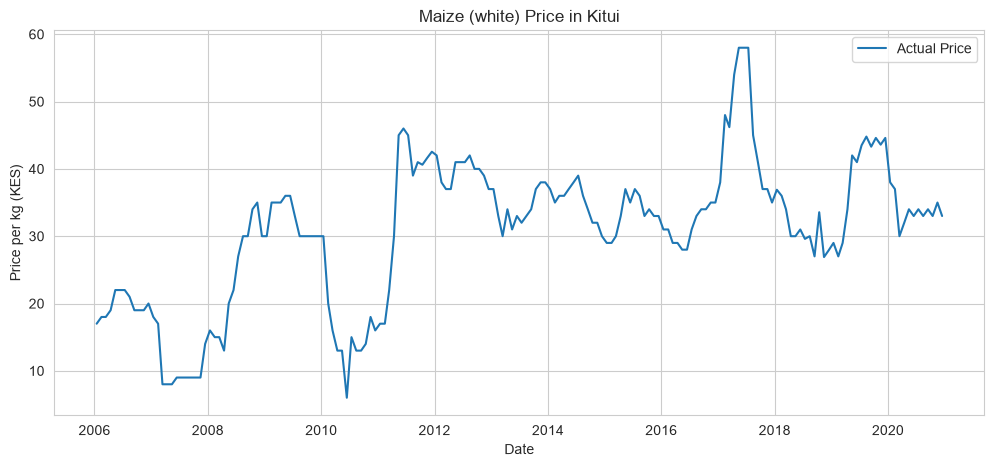

In [74]:
# Plot the historical price series
plt.figure(figsize=(12, 5))
plt.plot(
    series["date"],
    series["price_per_kg"],
    label="Actual Price"
)
plt.title(
    f"{commodity} Price in {market}"
)
plt.xlabel("Date")
plt.ylabel("Price per kg (KES)")
plt.legend()
plt.show()

### 4.6 Data preparaion for prophet

Prophet requires a dataframe containing a date column named `ds` and a target variable named `y`.

The standardized `price_per_kg` variable is therefore renamed to `y`, while the observation date is renamed to `ds`.

The weather variables are retained as additional regressors so that their contribution to price forecasting can be evaluated.


In [75]:
# Prepare the selected series for Prophet

prophet_data = series[
    [
        "date",
        "price_per_kg",
        "rainfall_lag_3",
        "rainfall_lag_4",
        "temperature_lag_3",
        "temperature_lag_4"
    ]
].copy()

# Rename columns according to Prophet's requirements
prophet_data = prophet_data.rename(
    columns={
        "date": "ds",
        "price_per_kg": "y"
    }
)

# Remove rows where weather regressors are unavailable.
# This is important because Prophet cannot train with missing regressor values.
prophet_data = prophet_data.dropna()

prophet_data.head()

,ds,y,rainfall_lag_3,rainfall_lag_4,temperature_lag_3,temperature_lag_4
20,2006-05-15,22.0,20.80,18.50,26.463214,25.264194
26,2006-06-15,22.0,62.83,20.80,25.200323,26.463214
31,2006-07-15,22.0,128.57,62.83,23.893667,25.200323
36,2006-08-15,21.0,100.14,128.57,23.305806,23.893667
41,2006-09-15,19.0,7.89,100.14,22.433000,23.305806


### 4.7 Prophet Train, Validation and Test Sets

The chronological structure of the data is preserved during model development.

The training set is used to estimate model parameters, the validation set is used for model development and parameter decisions, and the test set remains untouched until final evaluation.

This prevents future observations from influencing the model during training and provides a more realistic estimate of how the forecasting system will perform after deployment.


In [76]:
# Convert the series-specific chronological cut-off dates into timestamps
# Use quantiles based on the filtered 'series' data, not the global 'master' data

series_train_end = series["date"].quantile(0.8)
series_val_end = series["date"].quantile(0.9)

# Create chronological splits for the selected Prophet series

prophet_train = prophet_data[
    prophet_data["ds"] <= series_train_end
].copy()

prophet_val = prophet_data[
    (prophet_data["ds"] > series_train_end) &
    (prophet_data["ds"] <= series_val_end)
].copy()

prophet_test = prophet_data[
    prophet_data["ds"] > series_val_end
].copy()



In [77]:
print("Training observations:", len(prophet_train))
print("Validation observations:", len(prophet_val))
print("Test observations:", len(prophet_test))

Training observations: 140
Validation observations: 18
Test observations: 18


### 4.8 Prophet Baseline Model

Prophet is used as the primary baseline forecasting model because it is designed for time series containing trend and seasonal patterns and provides interpretable forecasts.

The model will first be trained using historical price information. Lagged weather variables are then added as external regressors because the Data Understanding phase investigated rainfall and temperature as potential drivers of food price movements.

The model is intentionally kept relatively simple at this stage. Hyperparameter tuning will only be considered after establishing a reliable baseline.


In [78]:
# Create the Prophet model

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

# Add lagged weather variables as external regressors.
# These variables were created during Data Preparation.

prophet_model.add_regressor("rainfall_lag_3")
prophet_model.add_regressor("rainfall_lag_4")
prophet_model.add_regressor("temperature_lag_3")
prophet_model.add_regressor("temperature_lag_4")

# Train the model using only the training data
prophet_model.fit(prophet_train)

13:15:26 - cmdstanpy - INFO - Chain [1] start processing
13:15:29 - cmdstanpy - INFO - Chain [1] done processing


### 4.9 Prophet Validation

The trained Prophet model is evaluated on the validation period to determine how accurately it predicts observations that were not included during training.

The validation results will be used to identify whether the model configuration is adequate before the final test evaluation.


In [79]:
# Generate predictions for the validation period

prophet_val_forecast = prophet_model.predict(
    prophet_val[
        [
            "ds",
            "rainfall_lag_3",
            "rainfall_lag_4",
            "temperature_lag_3",
            "temperature_lag_4"
        ]
    ]
)

# Combine predictions with actual prices

prophet_val_results = prophet_val[
    ["ds", "y"]
].copy()

prophet_val_results["prediction"] = (
    prophet_val_forecast["yhat"].values
)

# Calculate MAE
val_mae = mean_absolute_error(
    prophet_val_results["y"],
    prophet_val_results["prediction"]
)

# Calculate MAPE safely
non_zero = prophet_val_results["y"] != 0

val_mape = np.mean(
    np.abs(
        (
            prophet_val_results.loc[non_zero, "y"]
            - prophet_val_results.loc[non_zero, "prediction"]
        )
        / prophet_val_results.loc[non_zero, "y"]
    )
) * 100

print(f"Prophet Validation MAE: {val_mae:.2f}")
print(f"Prophet Validation MAPE: {val_mape:.2f}%")

Prophet Validation MAE: 8.64
Prophet Validation MAPE: 28.26%


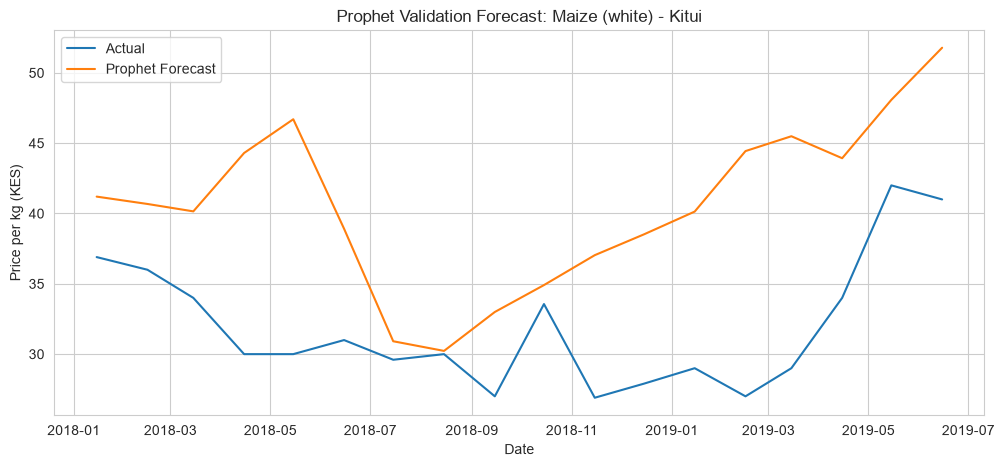

In [80]:
# Plot Prophet Validation Forecast
# Plot actual versus predicted validation prices

plt.figure(figsize=(12, 5))

plt.plot(
    prophet_val_results["ds"],
    prophet_val_results["y"],
    label="Actual"
)

plt.plot(
    prophet_val_results["ds"],
    prophet_val_results["prediction"],
    label="Prophet Forecast"
)

plt.title(
    f"Prophet Validation Forecast: {commodity} - {market}"
)

plt.xlabel("Date")
plt.ylabel("Price per kg (KES)")
plt.legend()
plt.show()

### 4.10 Final Prophet Test Evaluation

After the Prophet configuration has been established using the training and validation periods, the model is evaluated on the test period.

The test set represents the most recent unseen observations and therefore provides the most realistic estimate of the model's expected forecasting performance.

The test results will later be compared against the naive baseline and LSTM model.


In [81]:
# Generate forecasts for the untouched test period

prophet_test_forecast = prophet_model.predict(
    prophet_test[
        [
            "ds",
            "rainfall_lag_3",
            "rainfall_lag_4",
            "temperature_lag_3",
            "temperature_lag_4"
        ]
    ]
)

# Store actual and predicted values together

prophet_test_results = prophet_test[
    ["ds", "y"]
].copy()

prophet_test_results["prediction"] = (
    prophet_test_forecast["yhat"].values
)

# Calculate MAE
prophet_test_mae = mean_absolute_error(
    prophet_test_results["y"],
    prophet_test_results["prediction"]
)

# Calculate MAPE
non_zero = prophet_test_results["y"] != 0

prophet_test_mape = np.mean(
    np.abs(
        (
            prophet_test_results.loc[non_zero, "y"]
            - prophet_test_results.loc[non_zero, "prediction"]
        )
        / prophet_test_results.loc[non_zero, "y"]
    )
) * 100



In [82]:
print(f"Prophet Test MAE: {prophet_test_mae:.2f}")
print(f"Prophet Test MAPE: {prophet_test_mape:.2f}%")

Prophet Test MAE: 7.00
Prophet Test MAPE: 19.69%


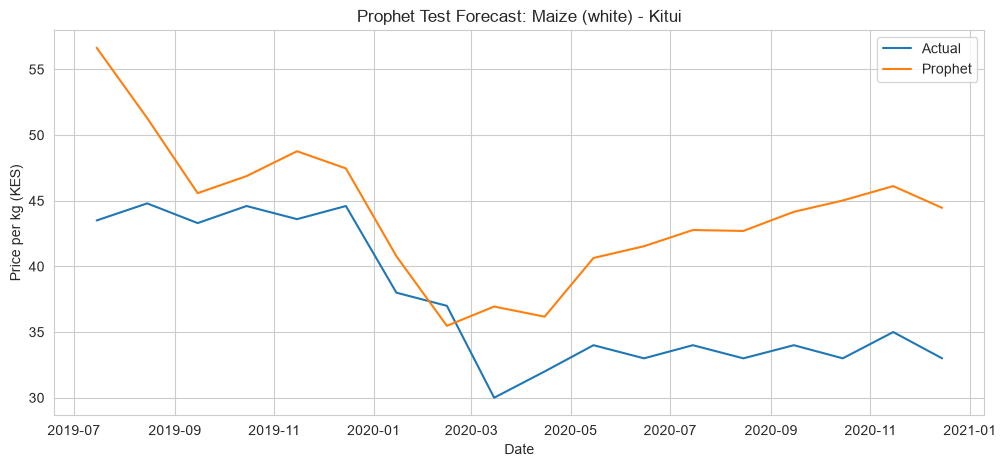

In [83]:
# plot the final prophet forecast
# Plot actual prices against Prophet predictions

plt.figure(figsize=(12, 5))

plt.plot(
    prophet_test_results["ds"],
    prophet_test_results["y"],
    label="Actual"
)

plt.plot(
    prophet_test_results["ds"],
    prophet_test_results["prediction"],
    label="Prophet"
)

plt.title(
    f"Prophet Test Forecast: {commodity} - {market}"
)

plt.xlabel("Date")
plt.ylabel("Price per kg (KES)")
plt.legend()
plt.show()

## 4.13 LSTM Forecasting Model

### 4.13.1 LSTM Modelling Objective

Long Short-Term Memory (LSTM) networks are recurrent neural networks designed to learn patterns from sequential data.

The LSTM model will be used as a comparison model to determine whether a neural-network-based approach can capture price dynamics that are not adequately represented by the Prophet baseline.

The model will use historical price and lagged weather variables as input features. The observations will be transformed into rolling sequences so that the model learns from a fixed number of previous months when predicting the next month's price.

The LSTM will be evaluated using the same chronological validation and test periods used for Prophet to ensure a fair comparison.


### 4.14 Prepare LSTM Features

### 4.14 Prepare LSTM Features

The LSTM model uses the historical food price together with lagged weather variables as input features.

The price variable is the prediction target, while rainfall and temperature provide additional information about recent environmental conditions that may influence food prices.

Only variables that are available from historical observations are used. Rows with missing modelling features are removed before sequence construction.

In [84]:
# Define the features used by the LSTM model.
# The first feature, price_per_kg, is the prediction target.

lstm_features = [
    "price_per_kg",
    "rainfall_lag_3",
    "rainfall_lag_4",
    "temperature_lag_3",
    "temperature_lag_4"
]

# Keep only the date and LSTM modelling features.
lstm_data = series[
    ["date"] + lstm_features
].copy()

# Remove rows with missing values in any modelling feature.
lstm_data = lstm_data.dropna(
    subset=lstm_features
)

# Sort observations chronologically.
lstm_data = lstm_data.sort_values("date").reset_index(drop=True)

# Check the resulting data.
print("LSTM data shape:", lstm_data.shape)

lstm_data.head()

LSTM data shape: (176, 6)


,date,price_per_kg,rainfall_lag_3,rainfall_lag_4,temperature_lag_3,temperature_lag_4
0,2006-05-15,22.0,20.80,18.50,26.463214,25.264194
1,2006-06-15,22.0,62.83,20.80,25.200323,26.463214
2,2006-07-15,22.0,128.57,62.83,23.893667,25.200323
3,2006-08-15,21.0,100.14,128.57,23.305806,23.893667
4,2006-09-15,19.0,7.89,100.14,22.433000,23.305806


### 4.15 Feature Scaling and Chronological Data Split

Because LSTM models are sensitive to differences in feature scale, the numerical variables are transformed using Min-Max scaling.

The data is divided chronologically into training, validation, and test periods. The scaler is fitted only on the training data and then applied unchanged to the validation and test sets.

This prevents information from the validation or test period from leaking into model training.

In [85]:
from sklearn.preprocessing import MinMaxScaler

# Define chronological boundaries.
# 80% of observations are used for training,
# 10% for validation, and the final 10% for testing.

train_end = lstm_data["date"].quantile(0.80)
val_end = lstm_data["date"].quantile(0.90)

# Create chronological masks.
train_mask = lstm_data["date"] <= train_end

val_mask = (
    (lstm_data["date"] > train_end) &
    (lstm_data["date"] <= val_end)
)

test_mask = lstm_data["date"] > val_end

# Split the data.
lstm_train = lstm_data[train_mask].copy()
lstm_val = lstm_data[val_mask].copy()
lstm_test = lstm_data[test_mask].copy()

# Create the scaler.
scaler = MinMaxScaler()

# IMPORTANT:
# Fit the scaler ONLY on training observations.
scaler.fit(lstm_train[lstm_features])

# Transform training, validation and test data
# using the training-fitted scaler.
train_scaled = scaler.transform(
    lstm_train[lstm_features]
)

val_scaled = scaler.transform(
    lstm_val[lstm_features]
)

test_scaled = scaler.transform(
    lstm_test[lstm_features]
)

# Display split sizes.
print("Training rows:", len(lstm_train))
print("Validation rows:", len(lstm_val))
print("Test rows:", len(lstm_test))

Training rows: 141
Validation rows: 17
Test rows: 18


In [86]:
# Number of previous months used to predict the next month
lookback = 6


def create_sequences(data, lookback):
    """
    Convert a scaled time series into rolling input sequences.

    Each sequence contains `lookback` previous observations.
    The target is the price immediately after that sequence.
    """

    X = []
    y = []

    for i in range(lookback, len(data)):
        # Previous observations become the model input
        X.append(data[i-lookback:i])

        # The next observation's first column is the target price
        y.append(data[i, 0])

    return np.array(X), np.array(y)


# Create training sequences
X_train, y_train = create_sequences(
    train_scaled,
    lookback
)

# Create validation sequences
X_val, y_val = create_sequences(
    val_scaled,
    lookback
)

# Create test sequences
X_test, y_test = create_sequences(
    test_scaled,
    lookback
)

In [87]:
print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Training shape: (135, 6, 5)
Validation shape: (11, 6, 5)
Test shape: (12, 6, 5)


### 4.16 Build the LSTM Network

Because some market–commodity series contain relatively few observations, a small LSTM architecture is used to reduce the risk of overfitting.

The model begins with only 8 LSTM units. Recurrent dropout and L2 kernel regularization are applied to further constrain the model. A dropout layer is also applied before the final prediction layer.

The architecture is intentionally kept small. Additional capacity will only be considered if validation performance demonstrates a meaningful improvement.

In [88]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.regularizers import l2

# Build a deliberately small LSTM model.
lstm_model = Sequential([
    
    LSTM(
        8,
        input_shape=(X_train.shape[1], X_train.shape[2]),
        return_sequences=False,
        
        # Drop connections within the recurrent computation.
        recurrent_dropout=0.2,
        
        # Penalize large LSTM weights.
        kernel_regularizer=l2(1e-4)
    ),
    
    # Additional regularization before the output.
    Dropout(0.2),
    
    # Predict the next price value.
    Dense(1)
])

# Compile the model.
lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Display model architecture and parameter count.
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8)              │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457 (1.79 KB)

 Trainable params: 457 (1.79 KB)

 Non-trainable params: 0 (0.00 B)

### 4.17 Train the LSTM Model

The LSTM is trained using the chronological training sequences while validation loss is monitored during training.

A small batch size of 4 is used because some market–commodity series contain relatively few training sequences. Early stopping with a patience of 3 epochs limits unnecessary training after validation performance stops improving.

The best validation weights are restored after training.

In [89]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training when validation loss stops improving.
# A patience of 3 prevents the model from continuing
# to memorize the training data for too many epochs.

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train the model.
history = lstm_model.fit(
    X_train,
    y_train,
    
    # Validation data is used only to monitor
    # generalization during training.
    validation_data=(X_val, y_val),
    
    # Maximum number of epochs.
    epochs=100,
    
    # Small batch size to reduce memorization.
    batch_size=4,
    
    callbacks=[early_stopping],
    verbose=1
)

print(
    f"Training stopped after {len(history.history['loss'])} epochs."
)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - loss: 0.1800 - mae: 0.3722 - val_loss: 0.1025 - val_mae: 0.3061
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0770 - mae: 0.2325 - val_loss: 0.0301 - val_mae: 0.1575
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0504 - mae: 0.1750 - val_loss: 0.0205 - val_mae: 0.1300
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0426 - mae: 0.1625 - val_loss: 0.0189 - val_mae: 0.1238
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0376 - mae: 0.1535 - val_loss: 0.0181 - val_mae: 0.1204
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0415 - mae: 0.1587 - val_loss: 0.0158 - val_mae: 0.1109
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0369 - mae: 0.1463 - val_loss: 0.0115 - val_mae: 0.0911
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0382 - mae: 0.1472 - val_loss: 0.0140 - val_mae: 0.1003
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.

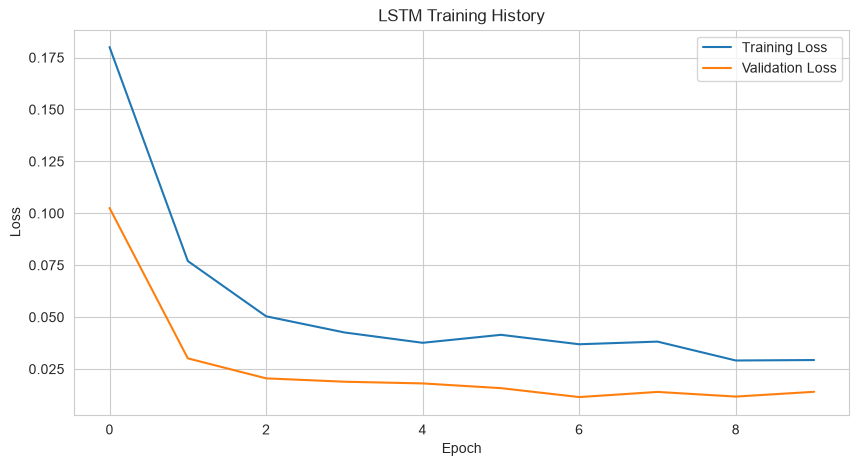

In [90]:
#Plot Training History
# Plot training and validation loss\


plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#### Training and Validation Loss Diagnostic

The training and validation loss curves are examined to determine the shape of the overfitting.

If validation loss improves for several epochs before increasing or becoming unstable while training loss continues to decrease, the model is likely beginning to overfit after learning useful patterns.

If validation loss remains high and flat from the beginning while training loss decreases, the model is failing to generalize and reducing model capacity or improving the data representation should be considered.

Best validation loss: 0.011489
Best epoch: 7


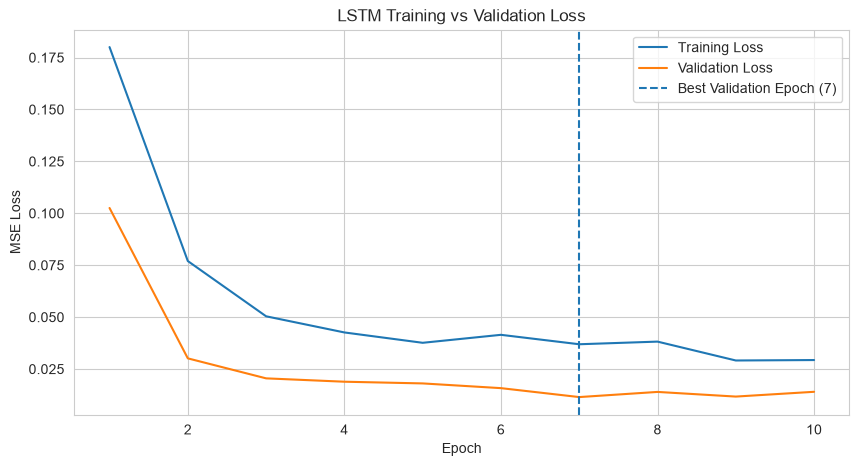

In [91]:
# Extract training and validation losses.
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

# Identify the epoch with the lowest validation loss.
best_epoch = np.argmin(val_loss) + 1
best_val_loss = min(val_loss)

print(f"Best validation loss: {best_val_loss:.6f}")
print(f"Best epoch: {best_epoch}")

# Plot training and validation loss.
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(train_loss) + 1),
    train_loss,
    label="Training Loss"
)

plt.plot(
    range(1, len(val_loss) + 1),
    val_loss,
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Validation Epoch ({best_epoch})"
)

plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

### 4.18 Evaluate LSTM

The trained LSTM is evaluated on the previously unseen test period.

Predictions are transformed back to the original KES/kg scale before calculating MAE and MAPE.

The LSTM is also compared with the naive baseline. The neural model should only be considered useful when it demonstrates an improvement over this simple benchmark.

In [93]:
# Compare LSTM performance with the naive baseline.
# This cell should only run after the LSTM predictions are created and the
# metrics have been computed in the following evaluation block.

if "lstm_mae" in globals() and "lstm_mape" in globals() and "naive_mae" in globals() and "naive_mape" in globals():
    print(f"LSTM Test MAE: {lstm_mae:.2f}")
    print(f"LSTM Test MAPE: {lstm_mape:.2f}%")

    print(f"\nNaive Test MAE: {naive_mae:.2f}")
    print(f"Naive Test MAPE: {naive_mape:.2f}%")

    if lstm_mae < naive_mae:
        print("\nLSTM beats the naive baseline on MAE.")
    else:
        print("\nLSTM does NOT beat the naive baseline on MAE.")
else:
    print("Run the LSTM prediction and evaluation cells first so lstm_mae/lstm_mape are defined.")

Run the LSTM prediction and evaluation cells first so lstm_mae/lstm_mape are defined.


In [94]:
# Generate predictions on the test set

lstm_predictions_scaled = lstm_model.predict(
    X_test
).flatten()


# Convert the scaled predictions back to original price units.
# A temporary matrix is created because the scaler was fitted
# on multiple features, not only the target.

prediction_matrix = np.zeros(
    (len(lstm_predictions_scaled), len(lstm_features))
)

# Put the predicted scaled price in the first column
prediction_matrix[:, 0] = lstm_predictions_scaled

# Inverse transform the predictions
lstm_predictions = scaler.inverse_transform(
    prediction_matrix
)[:, 0]


# Convert the scaled actual target values back to KES/kg

actual_matrix = np.zeros(
    (len(y_test), len(lstm_features))
)

actual_matrix[:, 0] = y_test

lstm_actual = scaler.inverse_transform(
    actual_matrix
)[:, 0]


# Calculate MAE
lstm_mae = mean_absolute_error(
    lstm_actual,
    lstm_predictions
)

# Calculate MAPE safely
non_zero = lstm_actual != 0

lstm_mape = np.mean(
    np.abs(
        (
            lstm_actual[non_zero]
            - lstm_predictions[non_zero]
        )
        / lstm_actual[non_zero]
    )
) * 100

print(f"LSTM Test MAE: {lstm_mae:.2f}")
print(f"LSTM Test MAPE: {lstm_mape:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 29s 29s/step
LSTM Test MAE: 2.07
LSTM Test MAPE: 6.23%


## 4.19 XGBoost Forecasting Model

Prophet and the LSTM both treat the series as ordered in time - Prophet decomposes trend and
seasonality directly, the LSTM reads a rolling window of past observations. XGBoost is
different: it is a gradient-boosted ensemble of decision trees over a flat table of
engineered features, so it has no built-in notion of sequence at all. Anything about recent
history or seasonality that the model should use has to be engineered into explicit columns.

The same demonstration series (Kitui, Maize (white)) is used here so its result slots
directly into the model comparison in 4.20, alongside the naive baseline, Prophet, and the
LSTM.


### 4.19.1 Prepare XGBoost Features

Six months of price history are engineered as explicit lag columns, since a tree ensemble
has no notion of "the last few observations" the way the LSTM's rolling window does - it only
ever sees a single flat row. The same rainfall and temperature lag features used by the LSTM
are reused here, and calendar month is added explicitly, since trees can't infer seasonality
from where a value sits in a sequence the way the LSTM implicitly can.


In [95]:
# Six months of price history, engineered as explicit lag columns.
# Unlike the LSTM's rolling window, XGBoost needs each lag as its own
# feature rather than a sequence, since a tree ensemble has no built-in
# notion of "the last few observations" - it only ever sees a flat row.
N_LAGS = 6

xgb_data = series.copy().sort_values("date").reset_index(drop=True)

for lag in range(1, N_LAGS + 1):
    xgb_data[f"price_lag_{lag}"] = xgb_data["price_per_kg"].shift(lag)

# Calendar month captures seasonality explicitly. The LSTM can pick this up
# implicitly from where a value sits in its rolling window; a tree ensemble
# needs it spelled out as its own column.
xgb_data["month"] = xgb_data["date"].dt.month

xgb_features = (
    [f"price_lag_{lag}" for lag in range(1, N_LAGS + 1)]
    + ["rainfall_lag_3", "rainfall_lag_4", "temperature_lag_3", "temperature_lag_4"]
    + ["month"]
)

xgb_target = "price_per_kg"

# Drop rows where any lag or weather feature is still unavailable
# (the first N_LAGS rows of the series, and any months missing weather data).
xgb_data = xgb_data.dropna(subset=xgb_features + [xgb_target]).reset_index(drop=True)

print("XGBoost feature rows:", len(xgb_data))
xgb_data[["date"] + xgb_features + [xgb_target]].head()

XGBoost feature rows: 174


,date,price_lag_1,price_lag_2,price_lag_3,price_lag_4,price_lag_5,price_lag_6,rainfall_lag_3,rainfall_lag_4,temperature_lag_3,temperature_lag_4,month,price_per_kg
0,2006-07-15,22.0,22.0,19.0,18.0,18.0,17.0,128.57,62.83,23.893667,25.200323,7,22.0
1,2006-08-15,22.0,22.0,22.0,19.0,18.0,18.0,100.14,128.57,23.305806,23.893667,8,21.0
2,2006-09-15,21.0,22.0,22.0,22.0,19.0,18.0,7.89,100.14,22.433000,23.305806,9,19.0
3,2006-10-15,19.0,21.0,22.0,22.0,22.0,19.0,9.12,7.89,21.474194,22.433000,10,19.0
4,2006-11-15,19.0,19.0,21.0,22.0,22.0,22.0,16.10,9.12,22.423226,21.474194,11,19.0


### 4.19.2 Chronological Train, Validation and Test Split

The same 80/10/10 chronological split used for Prophet (4.7) and the LSTM (4.15) is applied
here, computed on this feature table's own dates so the cut-offs land on rows that actually
survived the lag/dropna step above.


In [96]:
# Reuse the same 80/10/10 chronological split logic as Prophet (4.7) and the
# LSTM (4.15), computed on this feature table's own dates so the cut-offs
# line up with rows that have all six lags available.
xgb_train_end = xgb_data["date"].quantile(0.80)
xgb_val_end = xgb_data["date"].quantile(0.90)

xgb_train = xgb_data[xgb_data["date"] <= xgb_train_end]
xgb_val = xgb_data[(xgb_data["date"] > xgb_train_end) & (xgb_data["date"] <= xgb_val_end)]
xgb_test = xgb_data[xgb_data["date"] > xgb_val_end]

X_train_xgb, y_train_xgb = xgb_train[xgb_features], xgb_train[xgb_target]
X_val_xgb, y_val_xgb = xgb_val[xgb_features], xgb_val[xgb_target]
X_test_xgb, y_test_xgb = xgb_test[xgb_features], xgb_test[xgb_target]

print("Training rows:", len(xgb_train))
print("Validation rows:", len(xgb_val))
print("Test rows:", len(xgb_test))

Training rows: 139
Validation rows: 17
Test rows: 18


### 4.19.3 Train the XGBoost Model

Given how small this series is - the same concern that drove the LSTM's capacity cuts in
4.22.5 - the tree ensemble is kept shallow and regularized from the start, rather than tuned
down after the fact. A low `max_depth` limits how specific any single tree's rules can get,
`reg_alpha`/`reg_lambda` penalize overly confident leaf values, and a low learning rate paired
with early stopping on the validation set lets boosting stop as soon as validation error
stops improving, instead of continuing to add trees that only fit training noise.


In [97]:
# XGBRegressor is imported in the shared modelling imports cell (4.1).

# Kept deliberately shallow and regularized, for the same reason the LSTM's
# capacity was cut in 4.22.5: this series is small enough that an
# unconstrained model - deep trees with no regularization - would memorize
# the training rows rather than learn a generalizable pattern.
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=15,
    eval_metric="mae",
    random_state=42
)

# The validation set decides when to stop adding trees, the same role it
# plays for the LSTM's EarlyStopping callback in 4.17.
xgb_model.fit(
    X_train_xgb,
    y_train_xgb,
    eval_set=[(X_val_xgb, y_val_xgb)],
    verbose=False
)

print(f"Boosting stopped after {xgb_model.best_iteration + 1} trees.")

Boosting stopped after 40 trees.


### 4.19.4 Evaluate XGBoost

The trained model is scored on the untouched test period and compared against the naive
baseline, the same check applied to the LSTM in 4.18.


In [98]:
# Generate predictions on the untouched test period.
xgb_predictions = xgb_model.predict(X_test_xgb)

xgb_test_mae = mean_absolute_error(y_test_xgb, xgb_predictions)

non_zero = y_test_xgb != 0
xgb_test_mape = np.mean(
    np.abs(
        (y_test_xgb[non_zero] - xgb_predictions[non_zero])
        / y_test_xgb[non_zero]
    )
) * 100

print(f"XGBoost Test MAE: {xgb_test_mae:.2f}")
print(f"XGBoost Test MAPE: {xgb_test_mape:.2f}%")

print(f"\nNaive Test MAE: {naive_mae:.2f}")
print(f"Naive Test MAPE: {naive_mape:.2f}%")

if xgb_test_mae < naive_mae:
    print("\nXGBoost beats the naive baseline on MAE.")
else:
    print("\nXGBoost does NOT beat the naive baseline on MAE.")

XGBoost Test MAE: 2.60
XGBoost Test MAPE: 6.68%

Naive Test MAE: 8.54
Naive Test MAPE: 7.72%

XGBoost beats the naive baseline on MAE.


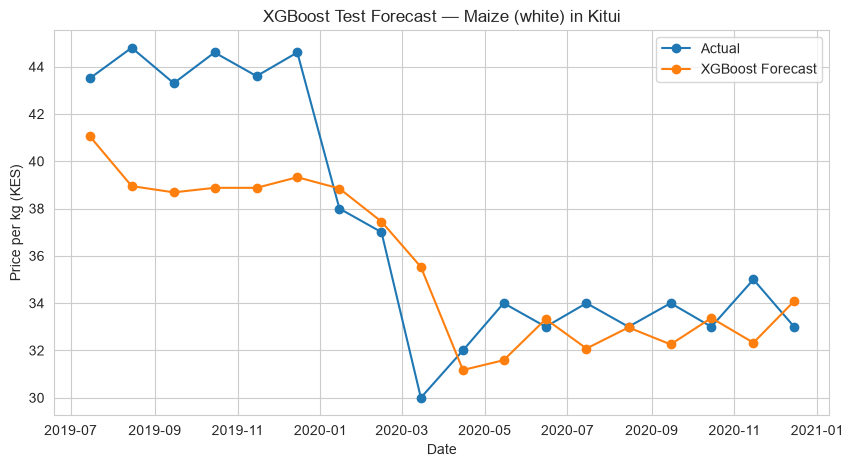

In [99]:
# Plot the final XGBoost forecast against actual test-period prices, the
# same visual check used for Prophet (4.10) and the LSTM.
plt.figure(figsize=(10, 5))
plt.plot(xgb_test["date"], y_test_xgb, label="Actual", marker="o")
plt.plot(xgb_test["date"], xgb_predictions, label="XGBoost Forecast", marker="o")
plt.title(f"XGBoost Test Forecast — {commodity} in {market}")
plt.xlabel("Date")
plt.ylabel("Price per kg (KES)")
plt.legend()
plt.show()

### 4.19.5 Feature Importance

One advantage a tree ensemble has over the LSTM is that its feature importances can be read
directly off the trained model, without a separate interpretability technique. This is a
useful sanity check: if `price_lag_1` dominates, the model is mostly leaning on "last month's
price", similar to the naive baseline; if the weather lags or `month` also carry meaningful
weight, that's evidence it's using more than recency alone.


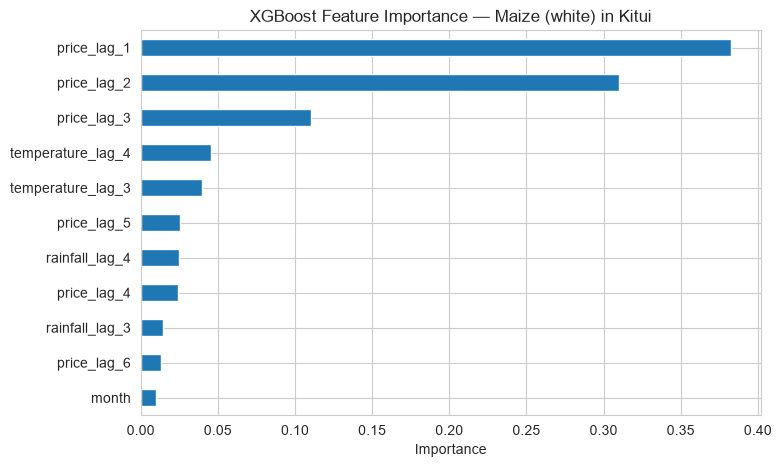

price_lag_1          0.382715
price_lag_2          0.310072
price_lag_3          0.110554
temperature_lag_4    0.045814
temperature_lag_3    0.039406
price_lag_5          0.025162
rainfall_lag_4       0.024560
price_lag_4          0.024077
rainfall_lag_3       0.014387
price_lag_6          0.013393
month                0.009860
dtype: float32

In [100]:
importances = pd.Series(
    xgb_model.feature_importances_,
    index=xgb_features
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.title(f"XGBoost Feature Importance — {commodity} in {market}")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

importances

## 4.20 Model Comparison

The candidate forecasting approaches are compared using the same chronological test period and consistent forecasting metrics.

The comparison includes:

1. **Naive baseline** — uses the most recent observed price as the forecast.
2. **Prophet** — models trend and seasonality and uses the selected weather variables.
3. **LSTM** — learns sequential relationships from historical price and lagged weather features.

MAE measures the average absolute forecasting error in price units, while MAPE expresses the average error as a percentage of the actual price.

The naive baseline provides the minimum benchmark that a more complex model should outperform. A model will only be considered preferable when its improvement is sufficiently consistent and meaningful rather than resulting from a single market–commodity pair.

In [101]:
# Create a comparison table for the four approaches

model_comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Prophet",
        "LSTM",
        "XGBoost"
    ],
    "MAE": [
        naive_mae,
        prophet_test_mae,
        lstm_mae,
        xgb_test_mae
    ],
    "MAPE": [
        naive_mape,
        prophet_test_mape,
        lstm_mape,
        xgb_test_mape
    ]
})

# Sort models by MAE
model_comparison = model_comparison.sort_values(
    "MAE"
).reset_index(drop=True)

model_comparison

,Model,MAE,MAPE
0,LSTM,2.066407,6.232762
1,XGBoost,2.602169,6.682012
2,Prophet,7.004282,19.690367
3,Naive Baseline,8.542707,7.715612


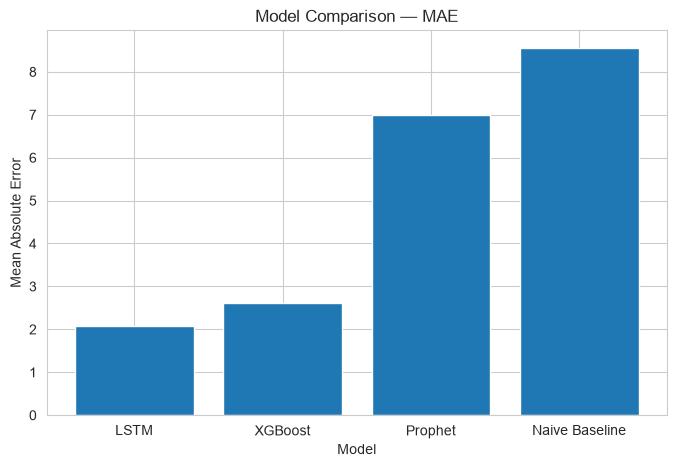

In [102]:
# Compare MAE across models

plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["MAE"]
)

plt.title("Model Comparison — MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")
plt.show()

### 4.21 Model Selection and Fallback Strategy

The final forecasting approach will not be selected solely on model complexity. Model selection will consider forecasting accuracy, validation stability, consistency across market–commodity combinations, computational requirements, interpretability, and suitability for deployment.

Prophet will remain unchanged and will be considered for the market–commodity series assigned to the Prophet track. The LSTM track will use the smaller regularized LSTM architecture and will only be retained where the model demonstrates stable validation performance and improves meaningfully over the naive baseline.

Very short or unstable series will not be forced into a neural-network forecast. If a smaller and regularized LSTM cannot generalize reliably for a particular market–commodity pair, that pair will use a naive or seasonal-naive forecast instead.

This fallback is treated as a modelling decision rather than a workaround. The purpose is to ensure that every deployed forecast is supported by sufficient historical information and demonstrates value over an appropriate baseline.

In [103]:
# Identify the model with the lowest MAE

best_model = model_comparison.loc[
    model_comparison["MAE"].idxmin(),
    "Model"
]

print(f"Best model for {commodity} in {market}: {best_model}")

Best model for Maize (white) in Kitui: LSTM


## 4.22 Batch Modelling Across Market–Commodity Pairs (LSTM Track)

After validating the modelling pipeline using the demonstration series, the same procedure will be applied across the shortlisted market–commodity combinations.

The model track created during Data Preparation will determine which forecasting approach is used for each series. Market–commodity pairs with at least three years of history will follow the Prophet track, while shorter but sufficiently complete series will follow the LSTM track.

For every series, the model performance will be recorded using MAE and MAPE. These results will then be aggregated to determine overall performance by model, commodity, market, and model track.


### 4.22.1 Encode Market and Commodity as Entities

Encoders are fit on `shortlist` rather than `master`, since a small number of shortlisted commodities (units not present in `unit_to_kg`, such as Milk (UHT)) get fully filtered out of `master` at the price-per-kg conversion step and never reach the modelling table. Fitting on `shortlist` ensures every pair the batch loop iterates over has a valid entity id, even if that pair is later skipped for having no usable rows.

In [104]:
from sklearn.preprocessing import LabelEncoder

market_encoder = LabelEncoder()
commodity_encoder = LabelEncoder()

market_encoder.fit(shortlist["market"])
commodity_encoder.fit(shortlist["commodity"])

master["market_id"] = master["market"].map(
    lambda m: market_encoder.transform([m])[0]
)
master["commodity_id"] = master["commodity"].map(
    lambda c: commodity_encoder.transform([c])[0]
)

n_markets = len(market_encoder.classes_)
n_commodities = len(commodity_encoder.classes_)

The resulting `market_id` and `commodity_id` columns are stable integer codes tied to the fitted encoders, so the same codes can later be reused at inference time on new data without retraining the encoders.

`n_markets` and `n_commodities` now reflect every entity in the shortlist, including any that end up contributing zero rows to the batch. This costs a slightly larger, mostly-unused embedding table for entities like Milk (UHT), but keeps `market_encoder.transform` and `commodity_encoder.transform` safe to call inside the 4.21.3 loop for every row of `shortlist`, without needing a try/except around the unseen-label case.

In [105]:
print(set(shortlist["commodity"]) - set(master["commodity"]))
print(set(shortlist["market"]) - set(master["market"]))

{'Milk (cow, fresh)', 'Fuel (kerosene)', 'Oil (vegetable)', 'Milk (camel, fresh)', 'Fuel (diesel)', 'Milk (cow, pasteurized)', 'Milk (UHT)', 'Bananas', 'Fuel (petrol-gasoline)'}
{'Dagahaley (Daadab)'}


### 4.22.2 Build Per-Pair Sequences and Diagnose Exclusions

Each shortlisted market–commodity pair is processed independently before the sequences are pooled.

The function applies the same chronological train, validation, and test logic to every pair and fits a separate scaler using only that pair's training observations.

Pairs that cannot produce usable sequences are not silently discarded. Instead, the reason for exclusion is recorded so that the effect of minimum-row and lookback requirements can be evaluated explicitly.

In [106]:
FEATURES = [
    "price_per_kg",
    "rainfall_lag_3",
    "rainfall_lag_4",
    "temperature_lag_3",
    "temperature_lag_4"
]

LOOKBACK = 6

# Minimum number of rows required before attempting
# sequence construction.
MIN_ROWS = LOOKBACK + 4


def build_pair_sequences(
    pair_df,
    market_id,
    commodity_id,
    model_track,
    lookback=LOOKBACK
):
    """
    Build train, validation and test sequences for one
    market–commodity pair.

    The function also records why a pair cannot be included.
    """

    # Sort chronologically and remove incomplete rows.
    pair_df = (
        pair_df
        .sort_values("date")
        .dropna(subset=FEATURES)
        .copy()
    )

    n_rows = len(pair_df)

    # ---------------------------------------------------------
    # CHECK 1: Minimum number of observations
    # ---------------------------------------------------------
    if n_rows < MIN_ROWS:
        return {
            "status": "excluded",
            "reason": "MIN_ROWS",
            "n_rows": n_rows,
            "market": pair_df["market"].iloc[0]
                if n_rows > 0 else None,
            "commodity": pair_df["commodity"].iloc[0]
                if n_rows > 0 else None,
            "model_track": model_track
        }

    # ---------------------------------------------------------
    # Chronological train / validation / test split
    # ---------------------------------------------------------
    train_end = pair_df["date"].quantile(0.80)
    val_end = pair_df["date"].quantile(0.90)

    train_mask = pair_df["date"] <= train_end

    val_mask = (
        (pair_df["date"] > train_end) &
        (pair_df["date"] <= val_end)
    )

    test_mask = pair_df["date"] > val_end

    # ---------------------------------------------------------
    # Naive baseline
    # ---------------------------------------------------------
    naive_pred = pair_df["price_per_kg"].shift(1)

    naive_ready = (
        test_mask &
        naive_pred.notna()
    )

    if not naive_ready.any():
        return {
            "status": "excluded",
            "reason": "NO_TEST_BASELINE",
            "n_rows": n_rows,
            "market": pair_df["market"].iloc[0],
            "commodity": pair_df["commodity"].iloc[0],
            "model_track": model_track
        }

    naive_actual = pair_df.loc[
        naive_ready,
        "price_per_kg"
    ]

    naive_pred_values = naive_pred.loc[
        naive_ready
    ]

    naive_mae = mean_absolute_error(
        naive_actual,
        naive_pred_values
    )

    non_zero_naive = naive_actual != 0

    naive_mape = np.mean(
        np.abs(
            (
                naive_actual[non_zero_naive]
                - naive_pred_values[non_zero_naive]
            )
            / naive_actual[non_zero_naive]
        )
    ) * 100

    # ---------------------------------------------------------
    # Fit scaler ONLY on training observations
    # ---------------------------------------------------------
    scaler = MinMaxScaler()

    scaler.fit(
        pair_df.loc[
            train_mask,
            FEATURES
        ]
    )

    train_scaled = scaler.transform(
        pair_df.loc[
            train_mask,
            FEATURES
        ]
    )

    val_scaled = scaler.transform(
        pair_df.loc[
            val_mask,
            FEATURES
        ]
    )

    test_scaled = scaler.transform(
        pair_df.loc[
            test_mask,
            FEATURES
        ]
    )

    # ---------------------------------------------------------
    # CHECK 2: Training data must contain enough rows
    # ---------------------------------------------------------
    if len(train_scaled) <= lookback:
        return {
            "status": "excluded",
            "reason": "TRAIN_LOOKBACK",
            "n_rows": n_rows,
            "n_train": len(train_scaled),
            "market": pair_df["market"].iloc[0],
            "commodity": pair_df["commodity"].iloc[0],
            "model_track": model_track
        }

    # ---------------------------------------------------------
    # Build training sequences
    # ---------------------------------------------------------
    X_train, y_train = create_sequences(
        train_scaled,
        lookback
    )

    # ---------------------------------------------------------
    # Validation sequences include the final training
    # lookback observations so that the first validation
    # prediction has historical context.
    # ---------------------------------------------------------
    if len(val_scaled) > 0:
        val_source = np.vstack([
            train_scaled[-lookback:],
            val_scaled
        ])

        X_val, y_val = create_sequences(
            val_source,
            lookback
        )
    else:
        X_val = np.empty(
            (0, lookback, len(FEATURES))
        )
        y_val = np.empty(0)

    # ---------------------------------------------------------
    # Test sequences also receive historical context.
    # ---------------------------------------------------------
    if len(test_scaled) > 0:

        if len(val_scaled) >= lookback:
            test_history = val_scaled[-lookback:]
        else:
            test_history = train_scaled[-lookback:]

        test_source = np.vstack([
            test_history,
            test_scaled
        ])

        X_test, y_test = create_sequences(
            test_source,
            lookback
        )

    else:
        X_test = np.empty(
            (0, lookback, len(FEATURES))
        )
        y_test = np.empty(0)

    # ---------------------------------------------------------
    # CHECK 3: Usable training and test sequences
    # ---------------------------------------------------------
    if len(X_train) < 1:
        return {
            "status": "excluded",
            "reason": "NO_TRAIN_SEQUENCES",
            "n_rows": n_rows,
            "n_train": len(train_scaled),
            "market": pair_df["market"].iloc[0],
            "commodity": pair_df["commodity"].iloc[0],
            "model_track": model_track
        }

    if len(X_test) == 0:
        return {
            "status": "excluded",
            "reason": "NO_TEST_SEQUENCES",
            "n_rows": n_rows,
            "n_train": len(train_scaled),
            "market": pair_df["market"].iloc[0],
            "commodity": pair_df["commodity"].iloc[0],
            "model_track": model_track
        }

    # ---------------------------------------------------------
    # Successful pair
    # ---------------------------------------------------------
    return {
        "status": "included",
        "reason": "usable",

        "market": pair_df["market"].iloc[0],
        "commodity": pair_df["commodity"].iloc[0],

        "market_id": market_id,
        "commodity_id": commodity_id,

        "model_track": model_track,

        "n_rows": n_rows,
        "n_train": len(train_scaled),
        "n_val": len(val_scaled),
        "n_test": len(test_scaled),

        "scaler": scaler,

        "naive_mae": naive_mae,
        "naive_mape": naive_mape,

        "X_train": X_train,
        "y_train": y_train,

        "X_val": X_val,
        "y_val": y_val,

        "X_test": X_test,
        "y_test": y_test
    }

Pairs that fail the minimum row requirement, or end up with no usable test sequences after the lookback window is applied, return `None` and are skipped in the next step. This mirrors the guard clauses already used in the original per-pair evaluation.

### 4.22.3 Build the LSTM Training Batch

Only market–commodity pairs assigned to the LSTM track are included in the shared LSTM training batch.

This separation is important because the model track assigned during Data Preparation determines which forecasting method should be applied to each pair. Prophet-track pairs are therefore not passed into the shared LSTM model.

The diagnostic also records the number of shortlisted pairs that are successfully included and the reasons for exclusions.

In [107]:
# ---------------------------------------------------------
# Keep only pairs assigned to the LSTM track.
# Prophet-track pairs are handled separately.
# ---------------------------------------------------------

lstm_shortlist = shortlist[
    shortlist["model_track"].str.lower() == "lstm"
].copy()

print(
    "LSTM pairs in shortlist:",
    len(lstm_shortlist)
)

# ---------------------------------------------------------
# Containers for pooled LSTM data.
# ---------------------------------------------------------

pair_bundles = []

X_train_list = []
y_train_list = []
mkt_train_list = []
com_train_list = []

X_val_list = []
y_val_list = []
mkt_val_list = []
com_val_list = []

X_test_list = []
y_test_list = []
mkt_test_list = []
com_test_list = []
pair_idx_test_list = []

# Store diagnostics for every shortlisted LSTM pair.
pair_diagnostics = []

# ---------------------------------------------------------
# Process each LSTM pair.
# ---------------------------------------------------------

for _, row in lstm_shortlist.iterrows():

    pair_df = master[
        (master["market"] == row["market"]) &
        (master["commodity"] == row["commodity"])
    ].copy()

    # Convert market and commodity names into entity IDs.
    market_id = market_encoder.transform(
        [row["market"]]
    )[0]

    commodity_id = commodity_encoder.transform(
        [row["commodity"]]
    )[0]

    # Build sequences for this pair.
    result = build_pair_sequences(
        pair_df=pair_df,
        market_id=market_id,
        commodity_id=commodity_id,
        model_track="lstm"
    )

    # -----------------------------------------------------
    # Record exclusion/inclusion diagnostics.
    # -----------------------------------------------------

    pair_diagnostics.append({
        "market": result.get("market"),
        "commodity": result.get("commodity"),
        "status": result["status"],
        "reason": result["reason"],
        "n_rows": result.get("n_rows", 0)
    })

    # Skip pairs that cannot produce usable sequences.
    if result["status"] == "excluded":
        continue

    bundle = result

    # Assign an index used later to identify test rows.
    pair_idx = len(pair_bundles)

    pair_bundles.append(bundle)

    # Number of sequences for this pair.
    n_train = len(bundle["X_train"])
    n_val = len(bundle["X_val"])
    n_test = len(bundle["X_test"])

    # -----------------------------------------------------
    # Training sequences
    # -----------------------------------------------------

    X_train_list.append(bundle["X_train"])
    y_train_list.append(bundle["y_train"])

    mkt_train_list.append(
        np.full(n_train, market_id)
    )

    com_train_list.append(
        np.full(n_train, commodity_id)
    )

    # -----------------------------------------------------
    # Validation sequences
    # -----------------------------------------------------

    if n_val > 0:
        X_val_list.append(bundle["X_val"])
        y_val_list.append(bundle["y_val"])

        mkt_val_list.append(
            np.full(n_val, market_id)
        )

        com_val_list.append(
            np.full(n_val, commodity_id)
        )

    # -----------------------------------------------------
    # Test sequences
    # -----------------------------------------------------

    X_test_list.append(bundle["X_test"])
    y_test_list.append(bundle["y_test"])

    mkt_test_list.append(
        np.full(n_test, market_id)
    )

    com_test_list.append(
        np.full(n_test, commodity_id)
    )

    pair_idx_test_list.append(
        np.full(n_test, pair_idx)
    )


# ---------------------------------------------------------
# Combine all LSTM sequences.
# ---------------------------------------------------------

X_train_all = np.concatenate(X_train_list)
y_train_all = np.concatenate(y_train_list)

market_train_all = np.concatenate(
    mkt_train_list
)

commodity_train_all = np.concatenate(
    com_train_list
)

X_val_all = (
    np.concatenate(X_val_list)
    if X_val_list
    else np.empty((0, LOOKBACK, len(FEATURES)))
)

y_val_all = (
    np.concatenate(y_val_list)
    if y_val_list
    else np.empty(0)
)

market_val_all = (
    np.concatenate(mkt_val_list)
    if mkt_val_list
    else np.empty(0, dtype=int)
)

commodity_val_all = (
    np.concatenate(com_val_list)
    if com_val_list
    else np.empty(0, dtype=int)
)

X_test_all = np.concatenate(
    X_test_list
)

y_test_all = np.concatenate(
    y_test_list
)

market_test_all = np.concatenate(
    mkt_test_list
)

commodity_test_all = np.concatenate(
    com_test_list
)

pair_idx_test_all = np.concatenate(
    pair_idx_test_list
)

print("\nLSTM batch created successfully.")
print("Training sequences:", len(X_train_all))
print("Validation sequences:", len(X_val_all))
print("Test sequences:", len(X_test_all))
print("Included LSTM pairs:", len(pair_bundles))

LSTM pairs in shortlist: 46

LSTM batch created successfully.
Training sequences: 122
Validation sequences: 33
Test sequences: 66
Included LSTM pairs: 33


#### LSTM Shortlist vs Included Diagnostic

The shortlist-to-included diagnostic verifies that the LSTM track is not being disproportionately filtered during sequence construction.

Each excluded pair is assigned an explicit reason, such as insufficient observations, insufficient training history for the lookback window, or absence of usable test sequences.

The expected result after the minimum-year floor fix is approximately 46 LSTM pairs in the shortlist. The number actually included depends on the available observations and sequence requirements.

In [108]:
# Convert diagnostics into a DataFrame.
diagnostic_df = pd.DataFrame(
    pair_diagnostics
)

# Count included and excluded pairs by reason.
diagnostic_summary = (
    diagnostic_df
    .groupby(
        ["status", "reason"]
    )
    .size()
    .reset_index(
        name="pairs"
    )
)

print(diagnostic_summary)

print("\nLSTM shortlist:", len(lstm_shortlist))

print(
    "LSTM included:",
    len(pair_bundles)
)

print(
    "LSTM excluded:",
    len(lstm_shortlist) - len(pair_bundles)
)

     status    reason  pairs
0  excluded  MIN_ROWS     13
1  included    usable     33

LSTM shortlist: 46
LSTM included: 33
LSTM excluded: 13


### 4.22.4 Global Entity-Embedding LSTM Architecture

A shared LSTM is used for the shortlisted LSTM-track market–commodity pairs.

The model receives three inputs:

1. Historical price and weather sequences.
2. Market identity.
3. Commodity identity.

Market and commodity identities are represented using small embedding layers. The LSTM branch is intentionally restricted to 8 units and uses recurrent dropout and L2 regularization. The embedding and dense layers are also regularized to reduce the risk of memorizing individual market–commodity identities.

The architecture starts at the smallest practical capacity. More units will only be considered if validation performance demonstrates a meaningful improvement.

In [109]:
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Flatten,
    Concatenate,
    LSTM,
    Dropout,
    Dense
)

from tensorflow.keras.models import Model

from tensorflow.keras.regularizers import l2


# Number of numerical features in each sequence.
n_features = len(FEATURES)

# Keep embedding dimensions deliberately small.
market_embed_dim = min(
    4,
    max(2, (n_markets + 1) // 2)
)

commodity_embed_dim = min(
    4,
    max(2, (n_commodities + 1) // 2)
)


# ---------------------------------------------------------
# Define model inputs.
# ---------------------------------------------------------

sequence_input = Input(
    shape=(LOOKBACK, n_features),
    name="sequence_input"
)

market_input = Input(
    shape=(1,),
    name="market_input"
)

commodity_input = Input(
    shape=(1,),
    name="commodity_input"
)


# ---------------------------------------------------------
# Market embedding.
# ---------------------------------------------------------

market_embed = Embedding(
    input_dim=n_markets,
    output_dim=market_embed_dim,
    embeddings_regularizer=l2(1e-4),
    name="market_embedding"
)(market_input)

market_embed = Flatten()(market_embed)


# ---------------------------------------------------------
# Commodity embedding.
# ---------------------------------------------------------

commodity_embed = Embedding(
    input_dim=n_commodities,
    output_dim=commodity_embed_dim,
    embeddings_regularizer=l2(1e-4),
    name="commodity_embedding"
)(commodity_input)

commodity_embed = Flatten()(commodity_embed)


# ---------------------------------------------------------
# Small regularized LSTM branch.
# ---------------------------------------------------------

lstm_out = LSTM(
    8,
    return_sequences=False,
    recurrent_dropout=0.2,
    kernel_regularizer=l2(1e-4)
)(sequence_input)

lstm_out = Dropout(0.2)(lstm_out)


# ---------------------------------------------------------
# Combine sequence and entity information.
# ---------------------------------------------------------

merged = Concatenate()([
    lstm_out,
    market_embed,
    commodity_embed
])


# ---------------------------------------------------------
# Small regularized dense layer.
# ---------------------------------------------------------

dense_out = Dense(
    8,
    activation="relu",
    kernel_regularizer=l2(1e-4)
)(merged)

dense_out = Dropout(0.2)(dense_out)


# Final price prediction.
output = Dense(1)(dense_out)


# ---------------------------------------------------------
# Create and compile the model.
# ---------------------------------------------------------

embedding_model = Model(
    inputs=[
        sequence_input,
        market_input,
        commodity_input
    ],
    outputs=output
)

embedding_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

embedding_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 6, 5)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ market_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ commodity_input     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 8)         │        448 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ market_embedding    │ (None, 1, 4)      │        108 │ market_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ commodity_embedding │ (None, 1, 4)      │         92 │ commodity_input[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 8)         │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4)         │          0 │ market_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 4)         │          0 │ commodity_embedd… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16)        │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │        136 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 8)         │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │          9 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 793 (3.10 KB)

 Trainable params: 793 (3.10 KB)

 Non-trainable params: 0 (0.00 B)

Embedding dimensions are capped at 8 and scaled to roughly half the number of unique entities, following the same rule of thumb used in tabular entity embedding work. With a small number of markets or commodities, this keeps the embedding space small enough to avoid overfitting on entity identity alone.

### 4.22.5 Train the Shared Entity-Embedding LSTM

The pooled model trains on sequences from every LSTM-track pair combined - 122 training
sequences across 33 pairs - which is a much larger and more heterogeneous training set than
any single pair's 8 to 12 sequences. `patience=3` and `batch_size=4` were carried over
directly from the per-pair fix in 4.17, but that combination stopped training after only 6
epochs, with validation loss still improving and a train/validation gap present from epoch
one. That pattern looks more like the model running out of time to find a shared
representation across pairs than like classic overfitting.

The pooled model therefore uses its own early-stopping patience and batch size, decoupled
from the per-pair settings: patience is raised so the model gets a fairer chance to prove
whether it can learn a shared representation, and batch size is raised to something more
appropriate for a training set two orders of magnitude larger than a single pair's.
Capacity and regularization (8 LSTM units, recurrent dropout, L2) are left exactly as they
were, since undertraining - not overfitting - is now the more likely explanation for the
pooled model's poor validation and test performance.

In [110]:
from tensorflow.keras.callbacks import EarlyStopping

# The per-pair patience=3 / batch_size=4 combination (from the single-pair LSTM
# in 4.17) was carried over here, but it isn't the right regime for the pooled
# batch: 122 training sequences across 33 pairs is a very different scale to a
# single pair's 8-12 sequences. Training previously stopped after only 6 epochs
# with validation loss still improving - a sign of undertraining, not
# overfitting - so these two settings are decoupled from the per-pair values.

# Give the pooled model more room to find a shared representation before
# giving up, instead of stopping almost immediately.
POOLED_PATIENCE = 8

# A pooled batch this size doesn't need per-pair-sized batches; a larger batch
# gives more stable gradient estimates per step across the mixed pairs.
POOLED_BATCH_SIZE = 16

embedding_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=POOLED_PATIENCE,
    restore_best_weights=True
)

# Train the shared LSTM model.
embedding_history = embedding_model.fit(
    [
        X_train_all,
        market_train_all,
        commodity_train_all
    ],
    y_train_all,

    validation_data=(
        [
            X_val_all,
            market_val_all,
            commodity_val_all
        ],
        y_val_all
    ),

    epochs=100,

    batch_size=POOLED_BATCH_SIZE,

    callbacks=[
        embedding_early_stopping
    ],

    verbose=1
)

print(
    "Training epochs:",
    len(
        embedding_history.history["loss"]
    )
)

# If validation loss still plateaus almost immediately at this patience and
# batch size, that's stronger evidence the problem is representational (the
# pooled architecture itself, or how heterogeneous the pooled pairs are)
# rather than simply needing more time to train - worth ruling in or out
# before touching capacity or regularization again.

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 292ms/step - loss: 0.3588 - mae: 0.5193 - val_loss: 2.1806 - val_mae: 1.0603
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.2877 - mae: 0.4651 - val_loss: 2.0455 - val_mae: 1.0031
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.2157 - mae: 0.3979 - val_loss: 1.8942 - val_mae: 0.9255
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1981 - mae: 0.3855 - val_loss: 1.7486 - val_mae: 0.8450
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1631 - mae: 0.3384 - val_loss: 1.6623 - val_mae: 0.7904
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1615 - mae: 0.3233 - val_loss: 1.6614 - val_mae: 0.7833
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1519 - mae: 0.3205 - val_loss: 1.6847 - val_mae: 0.7896
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1404 - mae: 0.3087 - val_loss: 1.6956 - val_mae: 0.7890
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1589 - mae

#### Entity-Embedding LSTM Training Diagnostic

The training and validation loss curves are inspected to determine whether the shared model is learning a generalizable representation across market–commodity pairs.

A useful training pattern is one where validation loss decreases during the early epochs and remains reasonably stable as training progresses.

If training loss continues to decrease while validation loss remains high and flat from the beginning, the shared model is not generalizing adequately. In that case, the smaller regularized architecture should be retained rather than adding model capacity.

Best validation loss: 1.661421
Best validation epoch: 6


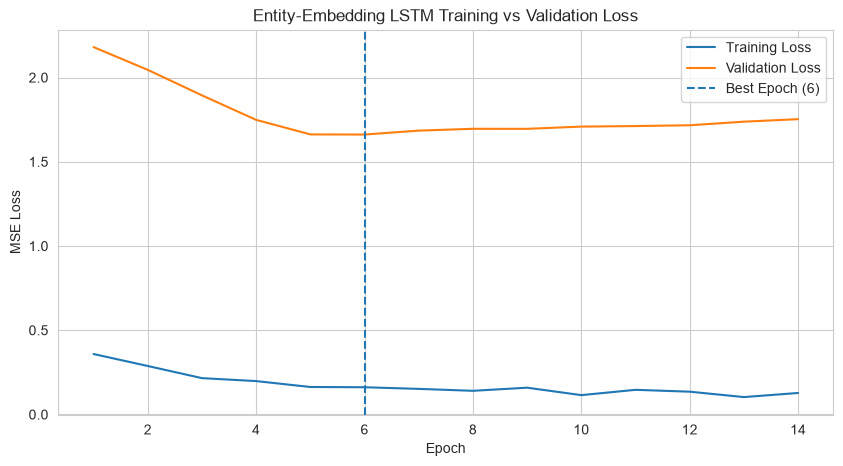

In [111]:
# Extract loss histories.
train_loss = embedding_history.history["loss"]
val_loss = embedding_history.history["val_loss"]

# Find the best validation epoch.
best_epoch = np.argmin(val_loss) + 1
best_val_loss = min(val_loss)

print(
    f"Best validation loss: {best_val_loss:.6f}"
)

print(
    f"Best validation epoch: {best_epoch}"
)

# Plot the curves.
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(train_loss) + 1),
    train_loss,
    label="Training Loss"
)

plt.plot(
    range(1, len(val_loss) + 1),
    val_loss,
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.title(
    "Entity-Embedding LSTM Training vs Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()
plt.show()

### 4.22.6 Per-Pair Evaluation

Although training happens once, evaluation still needs to happen per pair, since each pair has its own price scale and its own scaler. A single forward pass scores every pair's test rows at once, then `pair_idx_test_all` is used to slice out each pair's rows and invert them back to KES per kilogram using that pair's own fitted scaler.

In [112]:
# Generate predictions for all LSTM test sequences.
predictions_scaled = embedding_model.predict(
    [
        X_test_all,
        market_test_all,
        commodity_test_all
    ],
    verbose=0
).flatten()


embedding_results = []


# Evaluate every included pair independently.
for pair_idx, bundle in enumerate(pair_bundles):

    # Identify test observations belonging to this pair.
    row_mask = (
        pair_idx_test_all == pair_idx
    )

    if not row_mask.any():
        continue

    scaler = bundle["scaler"]

    # -----------------------------------------------------
    # Convert predictions back to original KES/kg units.
    # -----------------------------------------------------

    pred_matrix = np.zeros(
        (
            row_mask.sum(),
            len(FEATURES)
        )
    )

    pred_matrix[:, 0] = (
        predictions_scaled[row_mask]
    )

    pred = scaler.inverse_transform(
        pred_matrix
    )[:, 0]

    # -----------------------------------------------------
    # Convert actual values back to original units.
    # -----------------------------------------------------

    actual_matrix = np.zeros(
        (
            row_mask.sum(),
            len(FEATURES)
        )
    )

    actual_matrix[:, 0] = (
        y_test_all[row_mask]
    )

    actual = scaler.inverse_transform(
        actual_matrix
    )[:, 0]

    # -----------------------------------------------------
    # Calculate MAE.
    # -----------------------------------------------------

    mae = mean_absolute_error(
        actual,
        pred
    )

    # -----------------------------------------------------
    # Calculate MAPE safely.
    # -----------------------------------------------------

    non_zero = actual != 0

    mape = np.mean(
        np.abs(
            (
                actual[non_zero]
                - pred[non_zero]
            )
            / actual[non_zero]
        )
    ) * 100

    # -----------------------------------------------------
    # Compare with naive baseline.
    # -----------------------------------------------------

    beats_naive = (
        mae < bundle["naive_mae"]
    )

    embedding_results.append({
        "market": bundle["market"],
        "commodity": bundle["commodity"],
        "model_track": bundle["model_track"],

        "n_test": int(
            row_mask.sum()
        ),

        "embedding_mae": mae,
        "embedding_mape": mape,

        "naive_mae": bundle["naive_mae"],
        "naive_mape": bundle["naive_mape"],

        "beats_naive": beats_naive
    })


embedding_results = pd.DataFrame(
    embedding_results
)

embedding_results.head()

,market,commodity,model_track,n_test,embedding_mae,embedding_mape,naive_mae,naive_mape,beats_naive
0,Kangemi (Nairobi),Maize,lstm,2,2.288038,4.576077,0.000,0.000000,False
1,Kangemi (Nairobi),Maize flour,lstm,2,6.563293,10.592698,3.845,6.357514,False
2,Kangemi (Nairobi),Meat (beef),lstm,2,39.466837,7.232923,20.000,3.653199,False
3,Kangemi (Nairobi),Rice,lstm,2,4.044409,4.044409,0.000,0.000000,False
4,Kangemi (Nairobi),Salt,lstm,2,4.340093,8.680185,0.000,0.000000,False


Each row in `embedding_results` is now directly comparable to a row that `evaluate_pair` would have produced for the same market-commodity pair, which makes it possible to compare the shared embedding model against the per-pair models side by side further down.

### 4.22.7 Aggregate LSTM Performance

The shared LSTM is evaluated at the individual market–commodity level before aggregate performance is calculated.

This prevents a good result from one large series from hiding poor performance on shorter series.

Performance is summarized overall and by commodity. The proportion of pairs beating the naive baseline is also reported because a complex model should demonstrate value beyond a simple benchmark.

In [113]:
# ---------------------------------------------------------
# Overall LSTM performance.
# ---------------------------------------------------------

overall_mae = (
    embedding_results[
        "embedding_mae"
    ].mean()
)

overall_mape = (
    embedding_results[
        "embedding_mape"
    ].mean()
)

# Percentage of pairs where LSTM beats naive.
beat_rate = (
    embedding_results[
        "beats_naive"
    ].mean() * 100
)


# ---------------------------------------------------------
# Performance by commodity.
# ---------------------------------------------------------

by_commodity = (
    embedding_results
    .groupby("commodity")[
        [
            "embedding_mae",
            "embedding_mape"
        ]
    ]
    .mean()
    .sort_values("embedding_mae")
)


# ---------------------------------------------------------
# Display results.
# ---------------------------------------------------------

print(
    f"Overall mean LSTM MAE: "
    f"{overall_mae:.2f}"
)

print(
    f"Overall mean LSTM MAPE: "
    f"{overall_mape:.2f}%"
)

print(
    f"LSTM pairs beating naive baseline: "
    f"{beat_rate:.1f}%"
)

print("\nPerformance by commodity:")

display(by_commodity)

Overall mean LSTM MAE: 13.00
Overall mean LSTM MAPE: 10.46%
LSTM pairs beating naive baseline: 9.1%

Performance by commodity:


,embedding_mae,embedding_mape
commodity,,
Salt,3.023939,6.047878
Rice,4.089516,4.089516
Wheat flour,4.557155,6.598241
Maize,4.990162,9.130095
Maize flour,5.785272,9.354010
Sorghum,10.480177,13.100222
Sugar,15.337441,12.740400
Potatoes (Irish),16.789227,29.079804
Beans (dry),29.712954,23.636470


### 4.22.8 LSTM Modelling Decision

The LSTM is considered suitable only when it demonstrates stable validation behaviour and improves forecasting performance relative to the naive baseline.

If the shared LSTM does not provide consistent improvement, the model will not be forced into deployment simply because it is more complex. Short or unstable market–commodity series will instead use the appropriate naive or seasonal-naive fallback.

In [114]:
# Determine whether the shared LSTM provides
# meaningful value over the naive baseline.

if beat_rate >= 50:
    print(
        "LSTM beats the naive baseline for "
        f"{beat_rate:.1f}% of included pairs."
    )
else:
    print(
        "LSTM beats the naive baseline for only "
        f"{beat_rate:.1f}% of included pairs."
    )

print(
    "\nFinal decision should consider both "
    "validation stability and test performance."
)

LSTM beats the naive baseline for only 9.1% of included pairs.

Final decision should consider both validation stability and test performance.


## 4.23 Batch XGBoost Modelling Across Market–Commodity Pairs

The LSTM's batch step in 4.22 was restricted to the `lstm` track, because the sequence and
lookback windowing in `build_pair_sequences` needs a run of consecutive months before it can
form even one training example. XGBoost's lag features don't carry that same constraint as
tightly - a row only needs its own lag columns filled in, not a full rolling window - so this
batch step is run across the **entire shortlist, both tracks**, using one shared model with
`market_id` and `commodity_id` included as ordinary integer features rather than learned
embeddings. This also gives a direct, apples-to-apples comparison against the
entity-embedding LSTM's per-pair results from 4.22.6.


### 4.23.1 Build Per-Pair Tabular Features and Diagnose Exclusions

Each pair still needs its own naive baseline and its own chronological train/validation/test
split, so results stay comparable to every other model in this notebook. Unlike
`build_pair_sequences`, there's no scaler to fit here (tree ensembles don't need feature
scaling) and no lookback window to satisfy - just enough rows to have `N_LAGS` months of price
history before the first usable row.


In [115]:
N_LAGS = 6
MIN_ROWS_XGB = N_LAGS + 4  # mirrors the LSTM's MIN_ROWS margin (4.22.2), scaled to a shorter lag window

XGB_FEATURES = (
    [f"price_lag_{lag}" for lag in range(1, N_LAGS + 1)]
    + ["rainfall_lag_3", "rainfall_lag_4", "temperature_lag_3", "temperature_lag_4", "month"]
)


def build_pair_xgb_features(pair_df, market_id, commodity_id, model_track):
    """
    Build train, validation and test feature rows for one market-commodity
    pair, for the pooled XGBoost model.

    Mirrors build_pair_sequences (4.22.2) in spirit - same chronological
    split, same naive baseline, same exclusion diagnostics - but produces
    flat feature rows instead of rolling sequences, and needs no per-pair
    scaler.
    """

    pair_df = pair_df.sort_values("date").copy()

    for lag in range(1, N_LAGS + 1):
        pair_df[f"price_lag_{lag}"] = pair_df["price_per_kg"].shift(lag)

    pair_df["month"] = pair_df["date"].dt.month

    pair_df = pair_df.dropna(subset=XGB_FEATURES + ["price_per_kg"])

    n_rows = len(pair_df)

    # ---------------------------------------------------------
    # CHECK 1: Minimum number of observations
    # ---------------------------------------------------------
    if n_rows < MIN_ROWS_XGB:
        return {
            "status": "excluded",
            "reason": "MIN_ROWS_XGB",
            "n_rows": n_rows,
            "market": pair_df["market"].iloc[0] if n_rows > 0 else None,
            "commodity": pair_df["commodity"].iloc[0] if n_rows > 0 else None,
            "model_track": model_track
        }

    # ---------------------------------------------------------
    # Chronological train / validation / test split, same 80/10/10
    # boundaries used everywhere else in this notebook.
    # ---------------------------------------------------------
    train_end = pair_df["date"].quantile(0.80)
    val_end = pair_df["date"].quantile(0.90)

    train_mask = pair_df["date"] <= train_end
    val_mask = (pair_df["date"] > train_end) & (pair_df["date"] <= val_end)
    test_mask = pair_df["date"] > val_end

    # ---------------------------------------------------------
    # Naive baseline, computed the same way as build_pair_sequences (4.22.2),
    # so beats_naive stays comparable across the LSTM and XGBoost batches.
    # ---------------------------------------------------------
    naive_pred = pair_df["price_per_kg"].shift(1)
    naive_ready = test_mask & naive_pred.notna()

    if not naive_ready.any():
        return {
            "status": "excluded",
            "reason": "NO_TEST_BASELINE",
            "n_rows": n_rows,
            "market": pair_df["market"].iloc[0],
            "commodity": pair_df["commodity"].iloc[0],
            "model_track": model_track
        }

    naive_actual = pair_df.loc[naive_ready, "price_per_kg"]
    naive_pred_values = naive_pred.loc[naive_ready]

    naive_mae_pair = mean_absolute_error(naive_actual, naive_pred_values)

    non_zero_naive = naive_actual != 0
    naive_mape_pair = np.mean(
        np.abs(
            (naive_actual[non_zero_naive] - naive_pred_values[non_zero_naive])
            / naive_actual[non_zero_naive]
        )
    ) * 100

    # ---------------------------------------------------------
    # CHECK 2: Usable rows in both the training and test splits
    # ---------------------------------------------------------
    if train_mask.sum() == 0:
        return {
            "status": "excluded",
            "reason": "NO_TRAIN_ROWS",
            "n_rows": n_rows,
            "market": pair_df["market"].iloc[0],
            "commodity": pair_df["commodity"].iloc[0],
            "model_track": model_track
        }

    if test_mask.sum() == 0:
        return {
            "status": "excluded",
            "reason": "NO_TEST_ROWS",
            "n_rows": n_rows,
            "market": pair_df["market"].iloc[0],
            "commodity": pair_df["commodity"].iloc[0],
            "model_track": model_track
        }

    return {
        "status": "included",
        "reason": "usable",
        "market": pair_df["market"].iloc[0],
        "commodity": pair_df["commodity"].iloc[0],
        "market_id": market_id,
        "commodity_id": commodity_id,
        "model_track": model_track,
        "n_rows": n_rows,
        "n_train": int(train_mask.sum()),
        "n_val": int(val_mask.sum()),
        "n_test": int(test_mask.sum()),
        "naive_mae": naive_mae_pair,
        "naive_mape": naive_mape_pair,
        "train_df": pair_df.loc[train_mask],
        "val_df": pair_df.loc[val_mask],
        "test_df": pair_df.loc[test_mask]
    }

### 4.23.2 Build the XGBoost Training Batch

Every pair's feature rows are stacked into one shared table, with `market_id` and
`commodity_id` included as ordinary integer columns rather than learned embeddings - the
trees can split on these directly, the same way they would split on any other feature, to
separate one pair's price level and behaviour from another's.


In [116]:
xgb_pair_bundles = []
xgb_pair_diagnostics = []

train_frames, val_frames, test_frames = [], [], []

for _, row in shortlist.iterrows():

    pair_df = master[
        (master["market"] == row["market"]) &
        (master["commodity"] == row["commodity"])
    ].copy()

    market_id = market_encoder.transform([row["market"]])[0]
    commodity_id = commodity_encoder.transform([row["commodity"]])[0]

    result = build_pair_xgb_features(
        pair_df=pair_df,
        market_id=market_id,
        commodity_id=commodity_id,
        model_track=row["model_track"]
    )

    xgb_pair_diagnostics.append({
        "market": result.get("market"),
        "commodity": result.get("commodity"),
        "status": result["status"],
        "reason": result["reason"],
        "n_rows": result.get("n_rows", 0)
    })

    if result["status"] == "excluded":
        continue

    pair_idx = len(xgb_pair_bundles)
    xgb_pair_bundles.append(result)

    for split_name, frame_list in [
        ("train", train_frames),
        ("val", val_frames),
        ("test", test_frames)
    ]:
        split_df = result[f"{split_name}_df"].copy()
        split_df["market_id"] = market_id
        split_df["commodity_id"] = commodity_id
        split_df["pair_idx"] = pair_idx
        frame_list.append(split_df)

xgb_train_all = pd.concat(train_frames, ignore_index=True)
xgb_val_all = pd.concat(val_frames, ignore_index=True)
xgb_test_all = pd.concat(test_frames, ignore_index=True)

XGB_MODEL_FEATURES = XGB_FEATURES + ["market_id", "commodity_id"]

print("Training rows:", len(xgb_train_all))
print("Validation rows:", len(xgb_val_all))
print("Test rows:", len(xgb_test_all))
print("Included pairs:", len(xgb_pair_bundles))

Training rows: 3974
Validation rows: 490
Test rows: 538
Included pairs: 99


#### XGBoost Shortlist vs Included Diagnostic

In [117]:
xgb_diagnostic_df = pd.DataFrame(xgb_pair_diagnostics)

xgb_diagnostic_summary = (
    xgb_diagnostic_df
    .groupby(["status", "reason"])
    .size()
    .reset_index(name="pairs")
)

print(xgb_diagnostic_summary)

print("\nFull shortlist:", len(shortlist))
print("XGBoost included:", len(xgb_pair_bundles))
print("XGBoost excluded:", len(shortlist) - len(xgb_pair_bundles))

     status        reason  pairs
0  excluded  MIN_ROWS_XGB     76
1  included        usable     99

Full shortlist: 175
XGBoost included: 99
XGBoost excluded: 76


### 4.23.3 Train One Shared XGBoost Model Across All Pairs

The same reasoning that shaped the LSTM's architecture in 4.22.4-4.22.5 applies here: a
shallow, regularized model with early stopping on the pooled validation set, so boosting
stops as soon as it stops generalizing rather than continuing to fit noise in any one pair's
short history. Capacity is raised slightly from the single-pair demo (4.19.3), since this
model now has to represent many more pairs at once, but stays well short of an unconstrained
tree ensemble.


In [118]:
xgb_pooled_model = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=20,
    eval_metric="mae",
    random_state=42
)

xgb_pooled_model.fit(
    xgb_train_all[XGB_MODEL_FEATURES],
    xgb_train_all["price_per_kg"],
    eval_set=[(xgb_val_all[XGB_MODEL_FEATURES], xgb_val_all["price_per_kg"])],
    verbose=False
)

print(f"Boosting stopped after {xgb_pooled_model.best_iteration + 1} trees.")

Boosting stopped after 111 trees.


### 4.23.4 Per-Pair Evaluation

Although the model is trained once on the pooled batch, evaluation still happens per pair -
the same principle used for the LSTM in 4.22.6 - since a good aggregate score could otherwise
hide poor performance on individual, shorter series.


In [119]:
xgb_test_all["prediction"] = xgb_pooled_model.predict(
    xgb_test_all[XGB_MODEL_FEATURES]
)

xgb_results = []

for pair_idx, bundle in enumerate(xgb_pair_bundles):

    pair_rows = xgb_test_all[xgb_test_all["pair_idx"] == pair_idx]

    if len(pair_rows) == 0:
        continue

    mae = mean_absolute_error(
        pair_rows["price_per_kg"],
        pair_rows["prediction"]
    )

    non_zero = pair_rows["price_per_kg"] != 0
    mape = np.mean(
        np.abs(
            (pair_rows.loc[non_zero, "price_per_kg"] - pair_rows.loc[non_zero, "prediction"])
            / pair_rows.loc[non_zero, "price_per_kg"]
        )
    ) * 100

    xgb_results.append({
        "market": bundle["market"],
        "commodity": bundle["commodity"],
        "model_track": bundle["model_track"],
        "n_test": len(pair_rows),
        "xgb_mae": mae,
        "xgb_mape": mape,
        "naive_mae": bundle["naive_mae"],
        "naive_mape": bundle["naive_mape"],
        "beats_naive": mae < bundle["naive_mae"]
    })

xgb_results = pd.DataFrame(xgb_results)
xgb_results.head()

,market,commodity,model_track,n_test,xgb_mae,xgb_mape,naive_mae,naive_mape,beats_naive
0,Ethiopia (Kakuma),Beans (dry),prophet,4,12.664463,10.225129,8.3325,6.622435,False
1,Ethiopia (Kakuma),Maize,prophet,4,2.637177,4.396543,4.1675,6.735522,True
2,Ethiopia (Kakuma),Maize flour,prophet,4,3.016750,3.400639,2.6650,3.042882,False
3,Ethiopia (Kakuma),Rice,prophet,4,9.220346,7.426574,10.0000,8.209707,True
4,Ethiopia (Kakuma),Salt,prophet,4,5.758236,8.310105,5.0000,7.099982,False


### 4.23.5 Aggregate XGBoost Performance

Reported the same way as the LSTM's aggregate results in 4.22.7: overall mean error, the
share of pairs that beat the naive baseline, and a breakdown by commodity and by track, since
XGBoost is now being evaluated across both tracks rather than just the `lstm` track.


In [120]:
overall_xgb_mae = xgb_results["xgb_mae"].mean()
overall_xgb_mape = xgb_results["xgb_mape"].mean()
xgb_beat_rate = xgb_results["beats_naive"].mean() * 100

by_track_xgb = (
    xgb_results.groupby("model_track")[["xgb_mae", "xgb_mape"]].mean()
)

by_commodity_xgb = (
    xgb_results.groupby("commodity")[["xgb_mae", "xgb_mape"]]
    .mean()
    .sort_values("xgb_mae")
)

print(f"Overall mean XGBoost MAE: {overall_xgb_mae:.2f}")
print(f"Overall mean XGBoost MAPE: {overall_xgb_mape:.2f}%")
print(f"XGBoost pairs beating naive baseline: {xgb_beat_rate:.1f}%")

print("\nMean error by model track:")
print(by_track_xgb)

print("\nPerformance by commodity:")
display(by_commodity_xgb)

Overall mean XGBoost MAE: 8.38
Overall mean XGBoost MAPE: 6.44%
XGBoost pairs beating naive baseline: 43.4%

Mean error by model track:
              xgb_mae  xgb_mape
model_track                    
prophet      8.377684  6.440834

Performance by commodity:


,xgb_mae,xgb_mape
commodity,,
Bread,2.016395,1.831248
Maize (white),2.497321,4.962935
Wheat flour,2.804685,3.036137
Maize,3.980429,6.811048
Maize flour,4.041293,4.677239
Sugar,5.807344,3.933277
Salt,7.066647,9.972097
Potatoes (Irish),7.493435,9.357956
Beans (dry),8.340327,7.279516


### 4.23.6 XGBoost vs LSTM: Best Model per Pair

For LSTM-track pairs, three forecasters are now evaluated on the same basis: naive, the
shared entity-embedding LSTM (`embedding_results` from 4.22.6), and the shared XGBoost model
(`xgb_results` above). Prophet-track pairs are only compared against naive and XGBoost here,
since Prophet was evaluated on the single demonstration series only (4.10), not batch-run
across its whole track the way the LSTM and XGBoost are.


In [121]:
comparison = xgb_results.merge(
    embedding_results[["market", "commodity", "embedding_mae"]],
    on=["market", "commodity"],
    how="left"
)


def pick_best(row):
    candidates = {"naive": row["naive_mae"], "xgboost": row["xgb_mae"]}
    if pd.notna(row["embedding_mae"]):
        candidates["lstm"] = row["embedding_mae"]
    return min(candidates, key=candidates.get)


comparison["best_model"] = comparison.apply(pick_best, axis=1)

print("Best model per pair, across the full shortlist:")
print(comparison["best_model"].value_counts())

comparison[
    ["market", "commodity", "model_track", "naive_mae", "xgb_mae", "embedding_mae", "best_model"]
]

Best model per pair, across the full shortlist:
best_model
naive      56
xgboost    43
Name: count, dtype: int64


,market,commodity,model_track,naive_mae,xgb_mae,embedding_mae,best_model
0,Ethiopia (Kakuma),Beans (dry),prophet,8.332500,12.664463,NaN,naive
1,Ethiopia (Kakuma),Maize,prophet,4.167500,2.637177,NaN,xgboost
2,Ethiopia (Kakuma),Maize flour,prophet,2.665000,3.016750,NaN,naive
3,Ethiopia (Kakuma),Rice,prophet,10.000000,9.220346,NaN,xgboost
4,Ethiopia (Kakuma),Salt,prophet,5.000000,5.758236,NaN,naive
...,...,...,...,...,...,...,...
94,Mogadishu (Kakuma),Maize flour,prophet,3.750000,4.657814,NaN,naive
95,Mogadishu (Kakuma),Rice,prophet,25.835000,20.813599,NaN,xgboost
96,Mogadishu (Kakuma),Salt,prophet,12.500000,11.089156,NaN,xgboost
97,Mogadishu (Kakuma),Sugar,prophet,5.832500,6.139827,NaN,naive


**Reading this table:** `best_model` records which forecaster actually won for each specific
pair, not which one the project expected to win going in. If XGBoost's count comes out ahead
of both naive and the LSTM, that's a meaningful finding in its own right - a shallow,
regularized tree ensemble with explicit lag features may simply be a better fit than a shared
recurrent network for a project this data-constrained. That result should feed back into the
fallback strategy in 4.21, alongside the LSTM's own routing decision in 4.22.8, rather than
sit here as a side note.
